In [3]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit

import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


In [4]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [7]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index[0].date()} to {val_df.index[-1].date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} rows)")


Train: 2018-01-16 to 2023-11-01 (2116 rows)
Val:   2023-11-02 to 2025-01-27 (453 rows)
Test:  2025-01-28 to 2026-04-26 (454 rows)


In [9]:
def hybrid_qrnn_loss(y, q_hybrid, sigma_al, alpha):
    """
    Hybrid QRNN ALD NLL Loss
    y        : observed returns (tensor), shape (T,)
    q_hybrid : hybrid quantile estimate (tensor), shape (T,)
    sigma_al : scale parameter (scalar tensor)
    alpha    : quantile level in (0,1)
    """
    u = y - q_hybrid
    indicator  = (u < 0).float()
    rho_alpha  = u * (alpha - indicator)
    nll = (- torch.log(torch.tensor(alpha * (1 - alpha), dtype=torch.float32))
           + torch.log(sigma_al)
           + rho_alpha / sigma_al)
    return nll.mean()


def compute_hybrid_quantile_location_cross_si(y, X, beta1, beta2, beta3, fnn_model, psi):
    """
    Cross-lagged hybrid QRNN location -- SI (self-interaction) functional form.
    The CaViaR component uses the previous hybrid output as its autoregressive input.
    SI form: q_t = beta1 * q_{t-1}^H + beta2 * |y_{t-1}| + beta3 * q_{t-1}^H * |y_{t-1}|

    y      : raw log returns (T,)
    X      : normalised features (T, input_dim)
    beta1  : quantile persistence, constrained to (0,1)
    beta2  : magnitude impact, constrained to >=0
    beta3  : interaction term, constrained to >=0
    psi    : mixing weight, constrained to (0,1)
    fnn_model : FNN correction network
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)  # shape (T,)

    q_caviar_list = [torch.zeros(1)]
    q_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        # CaViaR component -- SI cross-lagged: uses previous hybrid output
        abs_y    = torch.abs(y[t-1])
        caviar_t = (beta1 * q_hybrid_list[t-1]
                  + beta2 * abs_y
                  + beta3 * q_hybrid_list[t-1] * abs_y)
        q_caviar_list.append(caviar_t)

        # Hybrid combination
        hybrid_t = psi * caviar_t + (1 - psi) * fnn_out[t]
        q_hybrid_list.append(hybrid_t)

    q_caviar = torch.stack(q_caviar_list).squeeze(-1)
    q_hybrid = torch.stack(q_hybrid_list).squeeze(-1)

    return q_hybrid, q_caviar

In [11]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

# Tuning

In [14]:
def compute_hybrid_quantile_location_cross_si(y, X, beta1, beta2, beta3, fnn_model, psi):
    """
    Cross-lagged hybrid QRNN location -- SI (self-interaction) functional form.
    The CaViaR component uses the previous hybrid output as its autoregressive input.
    SI form: q_t = beta1 * q_{t-1}^H + beta2 * |y_{t-1}| + beta3 * q_{t-1}^H * |y_{t-1}|
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)

    q_caviar_list = [torch.zeros(1)]
    q_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        abs_y    = torch.abs(y[t-1])
        caviar_t = (beta1 * q_hybrid_list[t-1]
                  + beta2 * abs_y
                  + beta3 * q_hybrid_list[t-1] * abs_y)
        q_caviar_list.append(caviar_t)

        hybrid_t = psi * caviar_t + (1 - psi) * fnn_out[t]
        q_hybrid_list.append(hybrid_t)

    q_caviar = torch.stack(q_caviar_list).squeeze(-1)
    q_hybrid = torch.stack(q_hybrid_list).squeeze(-1)

    return q_hybrid, q_caviar


class HybridQRNN_SI(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.beta3_raw = nn.Parameter(torch.tensor(0.3))     # interaction term
        self.psi_raw   = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = torch.nn.functional.softplus(self.beta2_raw)
        beta3 = torch.nn.functional.softplus(self.beta3_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = torch.nn.functional.softplus(self.sigma_raw)

        # cross-lagged SI: uses previous hybrid output
        q_hybrid, q_caviar = compute_hybrid_quantile_location_cross_si(
            y, X, beta1, beta2, beta3, self.fnn, psi)

        return q_hybrid, sigma


def compute_crp(y, q, alpha):
    """
    Coverage Ratio Penalty (CRP).
    For alpha <= 0.5: count violations where y <= q (lower tail).
    For alpha >  0.5: count violations where y >  q (upper tail).
    CRP = empirical_coverage / alpha*
    Penalty = (CRP - 1)^2
    """
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective_qrnn(trial, alpha):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)
    model = HybridQRNN_SI(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        crp, crp_penalty = compute_crp(y_val, q_val, alpha)

        beta1 = torch.sigmoid(model.beta1_raw).item()
        beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        beta3 = torch.nn.functional.softplus(model.beta3_raw).item()
        psi   = torch.sigmoid(model.psi_raw).item()
        sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('beta1',       beta1)
    trial.set_user_attr('beta2',       beta2)
    trial.set_user_attr('beta3',       beta3)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"alpha={alpha} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"beta1={beta1:.4f} | beta2={beta2:.4f} | beta3={beta3:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    for rank, t in enumerate(sorted(trials, key=lambda t: t._nll), start=1):
        t._rank_nll = rank

    for rank, t in enumerate(sorted(trials, key=lambda t: t._crp_penalty), start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


# -------------------------
# Run tuning for each alpha level
# -------------------------
alpha_levels               = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed                  = 2026
best_configs_qrnn_si_cross = {}  # distinct name for QRNN SI cross-lagged

for i, alpha in enumerate(alpha_levels):
    print(f"\n{'='*60}")
    print(f"Tuning QRNN SI Cross-lagged for alpha = {alpha} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, a=alpha: objective_qrnn(trial, alpha=a),
                   n_trials=200, show_progress_bar=True)

    best_trial, all_trials = select_best_trial_by_rank(study)

    print(f"\nRanking summary for alpha={alpha}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking to CSV
    ranking_records = []
    for t in all_trials:
        record = {
            'alpha':       alpha,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'beta1':       t.user_attrs['beta1'],
            'beta2':       t.user_attrs['beta2'],
            'beta3':       t.user_attrs['beta3'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    ranking_df.to_csv(f'qrnn_si_cross_ranking_alpha_{alpha}.csv', index=False)
    print(f"  Full ranking saved to qrnn_si_cross_ranking_alpha_{alpha}.csv")

    best_configs_qrnn_si_cross[alpha] = best_trial.params.copy()
    best_configs_qrnn_si_cross[alpha]['alpha'] = alpha

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)
    best_model = HybridQRNN_SI(X_train.shape[1], best_configs_qrnn_si_cross[alpha])

    if best_configs_qrnn_si_cross[alpha]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_qrnn_si_cross[alpha]['lr'],
                                     weight_decay=best_configs_qrnn_si_cross[alpha]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_qrnn_si_cross[alpha]['lr'],
                                      weight_decay=best_configs_qrnn_si_cross[alpha]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_qrnn_si_cross[alpha]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            q_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_qrnn_si_cross[alpha].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_qrnn_loss(y_val, q_val_final, sigma_val_final, alpha).item()
        final_crp, final_crp_penalty = compute_crp(y_val, q_val_final, alpha)

        est_beta1 = torch.sigmoid(best_model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(best_model.beta2_raw).item()
        est_beta3 = torch.nn.functional.softplus(best_model.beta3_raw).item()
        est_psi   = torch.sigmoid(best_model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_qrnn_si_cross[alpha]['est_psi']   = est_psi
    best_configs_qrnn_si_cross[alpha]['est_sigma']  = est_sigma
    best_configs_qrnn_si_cross[alpha]['est_beta1']  = est_beta1
    best_configs_qrnn_si_cross[alpha]['est_beta2']  = est_beta2
    best_configs_qrnn_si_cross[alpha]['est_beta3']  = est_beta3
    best_configs_qrnn_si_cross[alpha]['est_crp']    = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank: {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:   {est_psi:.4f}")
    print(f"Estimated sigma: {est_sigma:.4f}")
    print(f"Estimated beta1: {est_beta1:.4f}")
    print(f"Estimated beta2: {est_beta2:.4f}")
    print(f"Estimated beta3: {est_beta3:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE -- QRNN SI CROSS-LAGGED")
print("="*60)
for alpha, config in best_configs_qrnn_si_cross.items():
    print(f"alpha={alpha}: {config}")

[I 2026-07-12 17:10:41,996] A new study created in memory with name: no-name-d3479556-b8b8-43ae-acde-7ac9d6572404



Tuning QRNN SI Cross-lagged for alpha = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=3.6969 | CRP=0.0883 | CRP_penalty=0.8312 | alpha=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5002 | sigma=0.9737 | beta1=0.8001 | beta2=0.8540 | beta3=0.8547
[I 2026-07-12 17:10:45,553] Trial 0 finished with value: 3.696876049041748 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 3.696876049041748.
  Trial 1: NLL=3.6843 | CRP=0.0883 | CRP_penalty=0.8312 | alpha=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5070 | sigma=0.9554 | beta1=0.7973 | beta2=0.8501 | beta3=0.8458
[I 2026-07-12 17:11:03,236] Trial 1 finished with value: 3.684325695037842 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'layernorm

[I 2026-07-12 18:08:24,177] A new study created in memory with name: no-name-6deaa43d-c0fc-4e7f-848e-5eae180135fa


...

  Trial 0: NLL=1.8779 | CRP=0.2649 | CRP_penalty=0.5404 | alpha=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5402 | sigma=0.3078 | beta1=0.7503 | beta2=0.6739 | beta3=0.6887
[I 2026-07-13 00:52:54,696] Trial 0 finished with value: 1.8779351711273193 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 1.8779351711273193.
  Trial 1: NLL=2.1802 | CRP=2.2517 | CRP_penalty=1.5666 | alpha=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5260 | sigma=0.4177 | beta1=0.7672 | beta2=0.7205 | beta3=0.7396
[I 2026-07-13 00:53:13,370] Trial 1 finished with value: 2.1801576614379883 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.

[I 2026-07-13 04:48:55,796] A new study created in memory with name: no-name-15139d5f-1746-4308-987a-b09e95eccb5a



Best trial (rank-based): #144
  NLL rank: 11 | CRP rank: 13 | Sum: 24
Final NLL:          -2.2505
Final CRP:          0.9713
Final CRP penalty:  0.0008
Best params: {'n_hidden_layers': 1, 'activation': 'gelu', 'dropout': 0.00051150741824511, 'layernorm': False, 'weight_init': 'he', 'lr': 0.04485838005162585, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 3.45625795529882e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 145}
Estimated psi:   0.9611
Estimated sigma: 0.0024
Estimated beta1: 0.0344
Estimated beta2: 0.0689
Estimated beta3: 0.0213

Tuning QRNN SI Cross-lagged for alpha = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=2.4818 | CRP=5.9161 | CRP_penalty=24.1682 | alpha=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5090 | sigma=0.2887 | beta1=0.7609 | beta2=0.6330 | beta3=0.7038
[I 2026-07-13 05:06:16,469] Trial 0 finished with value: 2.4817726612091064 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 2.4817726612091064.
  Trial 1: NLL=3.6769 | CRP=0.0000 | CRP_penalty=1.0000 | alpha=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5030 | sigma=0.9562 | beta1=0.7986 | beta2=0.8576 | beta3=0.8493
[I 2026-07-13 05:06:33,876] Trial 1 finished with value: 3.676877975463867 and parameters: {'n_hidden_layers': 1, 'activation': 'el


Training final model for alpha = 0.025 (SI cross-lagged)
  Epoch 50: train=1.9764, val=1.9301
  Epoch 100: train=-0.0615, val=-0.1628
  Epoch 150: train=-1.5069, val=-1.6710
  Epoch 200: train=-2.0286, val=-2.1206
  Test loss: -2.1572 | Coverage ratio: 3.348 | beta1=0.0235 | beta2=0.0886 | beta3=0.0286 | psi=0.9625 | sigma=0.0016

Training final model for alpha = 0.05 (SI cross-lagged)
  Epoch 50: train=0.9294, val=0.9065
  Epoch 100: train=-1.2745, val=-1.4307
  Epoch 150: train=-1.8384, val=-1.7832
  Epoch 200: train=-2.1100, val=-2.2767
  Test loss: -2.4512 | Coverage ratio: 0.925 | beta1=0.0400 | beta2=0.0670 | beta3=0.0280 | psi=0.9684 | sigma=0.0023

Training final model for alpha = 0.25 (SI cross-lagged)
  Epoch 50: train=0.0685, val=0.0263
  Epoch 100: train=-1.6179, val=-1.7327
  Epoch 150: train=-2.2405, val=-1.3449
  Epoch 200: train=-2.3936, val=-2.0475
  Test loss: -2.5595 | Coverage ratio: 2.070 | beta1=0.0480 | beta2=0.0998 | beta3=0.0816 | psi=0.9414 | sigma=0.0075

Tr

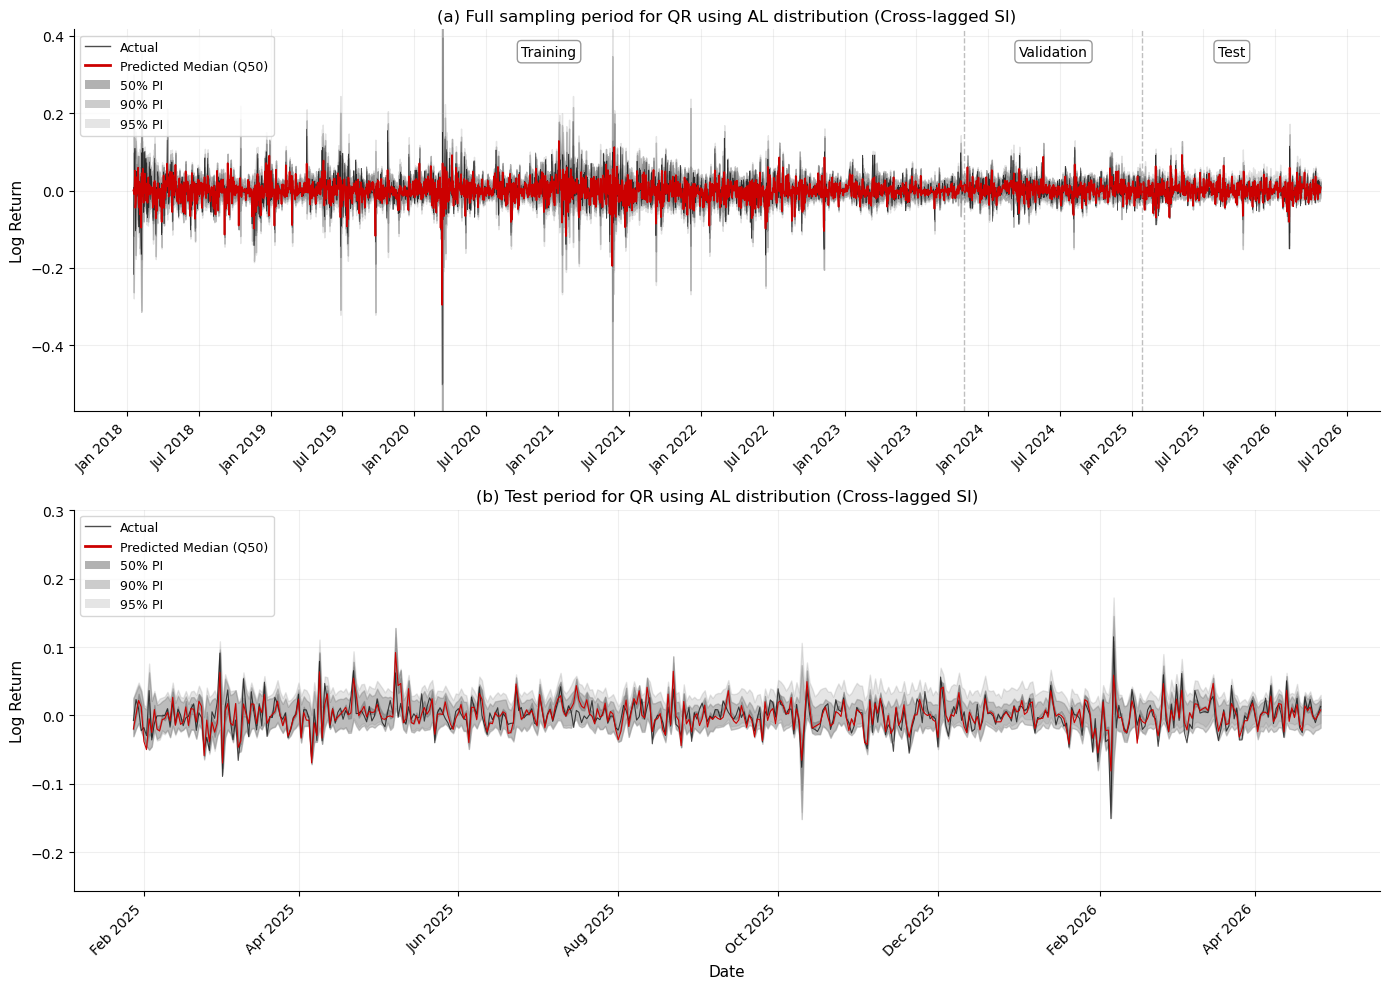

Full period plot saved to hybrid_qrnn_cross_si_predictions_full.png
Test period plot saved to hybrid_qrnn_cross_si_predictions_test.png

CROSSOVER ANALYSIS -- QRNN Cross SI (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):         400     88.11% <-- TAIL
  (0.050, 0.250):           0      0.00%
  (0.250, 0.500):         214     47.14%
  (0.500, 0.750):          37      8.15%
  (0.750, 0.950):          36      7.93%
  (0.950, 0.975):           4      0.88% <-- TAIL
  ------------------------------------------
  Total violations:         691  (25.37% of all pairs)
  Tail violations:          404  (44.49% of tail pairs)


In [16]:
def train_final_model_qrnn_si(alpha, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridQRNN_SI(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        q_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha)

        if alpha <= 0.5:
            coverage = (y_test <= q_test).float().mean().item()
        else:
            coverage = (y_test > q_test).float().mean().item()
        expected       = alpha if alpha <= 0.5 else 1 - alpha
        coverage_ratio = coverage / expected

    with torch.no_grad():
        est_beta1 = torch.sigmoid(model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        est_beta3 = torch.nn.functional.softplus(model.beta3_raw).item()
        est_psi   = torch.sigmoid(model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | Coverage ratio: {coverage_ratio:.3f} | "
          f"beta1={est_beta1:.4f} | beta2={est_beta2:.4f} | beta3={est_beta3:.4f} | "
          f"psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'qrnn_si_cross_history_alpha_{alpha}.csv', index=False)

    return model, train_losses, val_losses, q_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all alpha levels
# -------------------------
alpha_levels              = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_qrnn_si_cross     = {}

for alpha in alpha_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for alpha = {alpha} (SI cross-lagged)")
    print(f"{'='*60}")
    config = best_configs_qrnn_si_cross[alpha]
    model, train_losses, val_losses, q_test_pred = train_final_model_qrnn_si(
        alpha, config, y_train, X_train, y_val, X_val, y_test_q, X_test_q
    )
    results_qrnn_si_cross[alpha] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'q_test':       q_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols,
                        title_suffix='QR using AL distribution (Cross-lagged SI)',
                        save_fname='hybrid_qrnn_cross_si_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    alpha_levels = list(best_configs_qrnn_si_cross.keys())

    for alpha in alpha_levels:
        model = results_qrnn[alpha]['model']
        model.eval()
        with torch.no_grad():
            q_all, _ = model(y_all, X_all)
            all_preds[alpha] = q_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    y_min, y_max     = y_all_np.min(), y_all_np.max()
    y_range          = y_max - y_min
    y_label          = y_max + 0.25 * y_range
    test_dates       = test_df.index
    y_test_np        = test_df['log_return'].values
    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t        = y_max_t - y_min_t

    # ============================================================
    # Combined two-panel figure
    # ============================================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    ax = axes[0]
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=0.8)
    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {save_fname}")
    plt.show()
    plt.close()

    # ============================================================
    # Panel (a) -- full period separately
    # ============================================================
    fig_a, ax_a = plt.subplots(1, 1, figsize=(14, 5))
    ax_a.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax_a.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax_a.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax_a.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax_a.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax_a.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax_a.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.text(train_df.index[len(train_df)//2], y_label, 'Training',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(val_df.index[len(val_df)//2], y_label, 'Validation',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(test_df.index[len(test_df)//2], y_label, 'Test',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_a.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_a.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax_a.set_ylabel('Log Return', fontsize=11)
    ax_a.grid(True, alpha=0.2)
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    fname_a = save_fname.replace('.png', '_full.png')
    plt.tight_layout()
    plt.savefig(fname_a, dpi=300, bbox_inches='tight')
    print(f"Full period plot saved to {fname_a}")
    plt.close()

    # ============================================================
    # Panel (b) -- test period separately
    # ============================================================
    fig_b, ax_b = plt.subplots(1, 1, figsize=(14, 5))
    ax_b.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax_b.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax_b.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=0.8)
    if have_95:
        ax_b.fill_between(test_dates,
                          all_preds[0.025][train_size + val_size:],
                          all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax_b.fill_between(test_dates,
                          all_preds[0.05][train_size + val_size:],
                          all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax_b.fill_between(test_dates,
                          all_preds[0.25][train_size + val_size:],
                          all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_b.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_b.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_b.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax_b.set_xlabel('Date', fontsize=11)
    ax_b.set_ylabel('Log Return', fontsize=11)
    ax_b.grid(True, alpha=0.2)
    ax_b.spines['top'].set_visible(False)
    ax_b.spines['right'].set_visible(False)
    fname_b = save_fname.replace('.png', '_test.png')
    plt.tight_layout()
    plt.savefig(fname_b, dpi=300, bbox_inches='tight')
    print(f"Test period plot saved to {fname_b}")
    plt.close()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- SI cross-lagged
# -------------------------
all_preds_qrnn_si_cross, train_size, val_size = plot_two_panel_qrnn(
    results_qrnn_si_cross, train_df, val_df, test_df, feature_cols,
    title_suffix='QR using AL distribution (Cross-lagged SI)',
    save_fname='hybrid_qrnn_cross_si_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='QRNN'):
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]
    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


total_viol, tail_viol = compute_crossovers(
    all_preds_qrnn_si_cross, alpha_levels, train_size, val_size,
    model_name='QRNN Cross SI'
)

In [18]:
import numpy as np


def compute_hre(y_true, q_pred, alpha):
    """
    Hit Rate Error for quantile evaluation.
    HRE = |mean(1(q_hat > y)) - alpha|
    """
    y        = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    q        = q_pred if isinstance(q_pred, np.ndarray) else np.array(q_pred)
    hit_rate = np.mean(q > y)
    hre      = np.abs(hit_rate - alpha)
    return hre


def compute_test_metrics_qrnn(results, alpha_levels, y_test, X_test, model_name='QRNN'):
    """
    Compute average NLL and HRE on test set across all alpha levels.
    """
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'alpha':>6} {'NLL':>10} {'HRE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    hre_list = []

    for alpha in alpha_levels:
        model = results[alpha]['model']
        model.eval()

        with torch.no_grad():
            q_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha).item()

        q_test_np = q_test.numpy()
        y_test_np = y_test.numpy()

        hre = compute_hre(y_test_np, q_test_np, alpha)

        nll_list.append(test_nll)
        hre_list.append(hre)

        print(f"  {alpha:>6} {test_nll:>10.4f} {hre:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(hre_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average HRE: {np.mean(hre_list):.6f}")

    return np.mean(nll_list), np.mean(hre_list)


# -------------------------
# Test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]

# -------------------------
# Run metrics -- QRNN SI cross-lagged
# -------------------------
avg_nll_qrnn_si_cross, avg_hre_qrnn_si_cross = compute_test_metrics_qrnn(
    results_qrnn_si_cross, alpha_levels, y_test_q, X_test_q,
    model_name='QRNN SI Cross-lagged'
)


TEST SET METRICS -- QRNN SI Cross-lagged
   alpha        NLL            HRE
  ----------------------------------
   0.025    -2.1572       0.058700
    0.05    -2.4512       0.003744
    0.25    -2.5595       0.267621
     0.5    -2.7435       0.006608
    0.75    -2.7166       0.020925
    0.95    -2.4202       0.010352
   0.975    -2.1717       0.025000
  ----------------------------------
    Mean    -2.4600       0.056136

  --> Average NLL: -2.4600
  --> Average HRE: 0.056136


# Crossover - Sorting


In [13]:
# ============================================================
# SORTING SETUP — HYBRID QRNN SI CROSS-LAGGED
# Recovers selected architectures; Optuna is not rerun
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

class HybridQRNN_SI(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.beta3_raw = nn.Parameter(torch.tensor(0.3))     # interaction term
        self.psi_raw   = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = torch.nn.functional.softplus(self.beta2_raw)
        beta3 = torch.nn.functional.softplus(self.beta3_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = torch.nn.functional.softplus(self.sigma_raw)

        # cross-lagged SI: uses previous hybrid output
        q_hybrid, q_caviar = compute_hybrid_quantile_location_cross_si(
            y, X, beta1, beta2, beta3, self.fnn, psi)

        return q_hybrid, sigma

X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

sorting_levels = [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975]
best_configs_qrnn_si_cross = {}

def _sorting_bool(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes"}

for level in sorting_levels:
    ranking_path = Path(f"qrnn_si_cross_ranking_alpha_{level}.csv".replace("{level}", str(level)))
    if not ranking_path.exists():
        raise FileNotFoundError(f"Missing ranking file: {ranking_path}")
    table = pd.read_csv(ranking_path)
    order = [c for c in ["sum_rank", "nll", "crp_penalty", "trial"] if c in table.columns]
    selected = table.sort_values(order).reset_index(drop=True).iloc[0]
    n_layers = int(selected["n_hidden_layers"])
    config = {
        "n_hidden_layers": n_layers,
        "activation": str(selected["activation"]),
        "dropout": float(selected["dropout"]),
        "layernorm": _sorting_bool(selected["layernorm"]),
        "weight_init": str(selected["weight_init"]),
        "lr": float(selected["lr"]),
        "optimizer": str(selected["optimizer"]).lower(),
        "batch_size": int(selected["batch_size"]),
        "weight_decay": float(selected["weight_decay"]),
        "gradient_clip": float(selected["gradient_clip"]),
        "patience": int(selected["patience"]),
        "alpha": level,
    }
    for layer_index in range(n_layers):
        config[f"hidden_dim_{layer_index}"] = int(selected[f"hidden_dim_{layer_index}"])
    best_configs_qrnn_si_cross[level] = config
    print(f"alpha={level:.3f}: trial #{int(selected['trial'])} recovered; NLL={selected['nll']:.6f}")

print("\nSORTING SETUP COMPLETE — Hybrid QRNN SI cross-lagged")
print("Recovered configurations:", len(best_configs_qrnn_si_cross))
print("Test observations:", len(y_test_q))


alpha=0.025: trial #192 recovered; NLL=-2.120602
alpha=0.050: trial #166 recovered; NLL=-2.279443
alpha=0.250: trial #162 recovered; NLL=-2.527403
alpha=0.500: trial #131 recovered; NLL=-2.600060
alpha=0.750: trial #191 recovered; NLL=-2.571545
alpha=0.950: trial #144 recovered; NLL=-2.250464
alpha=0.975: trial #175 recovered; NLL=-2.208102

SORTING SETUP COMPLETE — Hybrid QRNN SI cross-lagged
Recovered configurations: 7
Test observations: 454


Refitting selected Hybrid QRNN SI cross-lagged: level=0.025
Refitting selected Hybrid QRNN SI cross-lagged: level=0.050
Refitting selected Hybrid QRNN SI cross-lagged: level=0.250
Refitting selected Hybrid QRNN SI cross-lagged: level=0.500
Refitting selected Hybrid QRNN SI cross-lagged: level=0.750
Refitting selected Hybrid QRNN SI cross-lagged: level=0.950
Refitting selected Hybrid QRNN SI cross-lagged: level=0.975


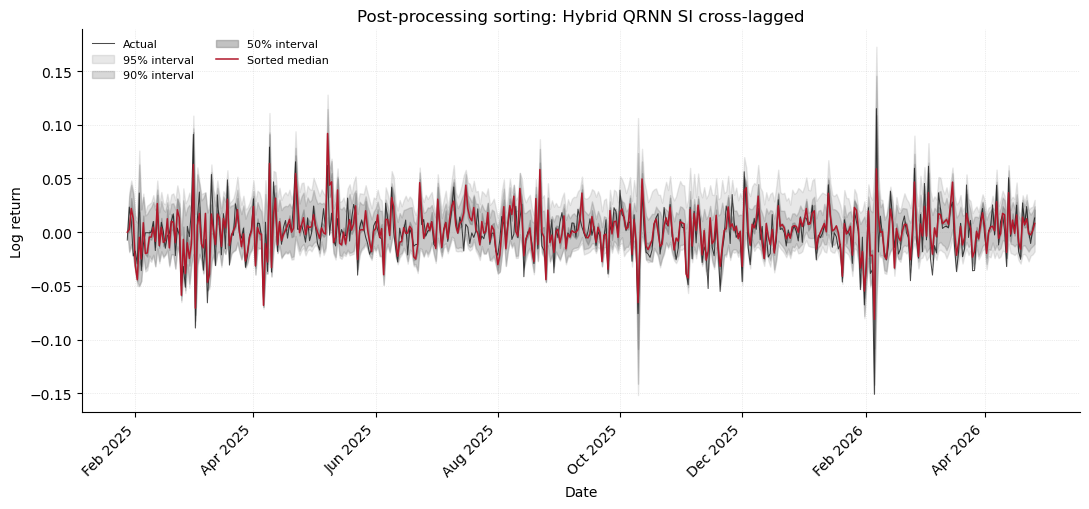


SORTING RESULTS — Hybrid QRNN SI cross-lagged
     level  raw_test_nll  sorted_test_nll    raw_hre  sorted_hre  mean_absolute_adjustment  maximum_absolute_adjustment
0.02500000   -2.15723634      -2.24932742 0.05870044  0.02125551                0.00325759                   0.01055108
0.05000000   -2.45117855      -2.42456627 0.00374449  0.03149780                0.00319783                   0.01055108
0.25000000   -2.55945039      -2.62032533 0.26762115  0.19713656                0.00181042                   0.01113652
0.50000000   -2.74347043      -2.75575113 0.00660793  0.06607930                0.00151433                   0.01004912
0.75000000   -2.71661663      -2.74216557 0.02092511  0.01211454                0.00109667                   0.03585583
0.95000000   -2.42023754      -2.41803908 0.01035242  0.01475771                0.00050497                   0.02268513
0.97500000   -2.17169738      -2.17073250 0.02500000  0.02500000                0.00005754                   0.01

In [15]:
# ============================================================
# POST-PROCESSING SORTING — HYBRID QRNN SI CROSS-LAGGED
# Refits seven selected architectures only; no Optuna search
# ============================================================

import copy
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sorting_output_dir = Path("sorting_crossover_results/qrnn_si_cross")
sorting_output_dir.mkdir(parents=True, exist_ok=True)

def _sorting_refit(level, config):
    torch.manual_seed(2026)
    np.random.seed(2026)
    model = HybridQRNN_SI(X_train.shape[1], config)
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    optimizer = optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, best_state, wait = float("inf"), None, 0
    for epoch in range(200):
        model.train(); optimizer.zero_grad()
        forecast, scale = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, forecast, scale, level)
        if not torch.isfinite(loss):
            raise RuntimeError(f"Invalid training loss at level={level}")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_forecast, val_scale = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, val_forecast, val_scale, level)
        scheduler.step(val_loss)
        value = val_loss.item()
        if value < best_loss:
            best_loss, best_state, wait = value, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= config.get("patience", 30):
                break
    if best_state is None:
        raise RuntimeError(f"No valid fitted state at level={level}")
    model.load_state_dict(best_state); model.eval()
    return model, best_loss

raw_columns, scales, validation_losses, fitted_models = [], {}, {}, {}
for level in sorting_levels:
    print(f"Refitting selected Hybrid QRNN SI cross-lagged: level={level:.3f}")
    model, validation_loss = _sorting_refit(level, best_configs_qrnn_si_cross[level].copy())
    with torch.no_grad():
        forecast, scale = model(y_test_q, X_test_q)
    raw_columns.append(forecast.detach().cpu().numpy().reshape(-1))
    scales[level] = float(scale.detach().cpu().item())
    validation_losses[level] = validation_loss
    fitted_models[level] = model

raw_matrix = np.column_stack(raw_columns)
sorted_matrix = np.sort(raw_matrix, axis=1)
actual = y_test_q.detach().cpu().numpy().reshape(-1)

def _sorting_calibration(actual, forecast, level):
    return float(abs(np.mean(actual < forecast) - level))

def _sorting_crossovers(matrix, kind):
    rows = []
    for j in range(len(sorting_levels) - 1):
        violations = matrix[:, j] > matrix[:, j + 1]
        rows.append({
            "forecast_type": kind,
            "lower_level": sorting_levels[j],
            "upper_level": sorting_levels[j + 1],
            "violations": int(violations.sum()),
            "violation_rate": float(violations.mean()),
            "tail_pair": j in (0, len(sorting_levels) - 2),
        })
    return pd.DataFrame(rows)

raw_cross = _sorting_crossovers(raw_matrix, "Unconstrained")
sorted_cross = _sorting_crossovers(sorted_matrix, "Sorted")
metric_rows = []
for j, level in enumerate(sorting_levels):
    raw_t = torch.tensor(raw_matrix[:, j], dtype=y_test_q.dtype)
    sorted_t = torch.tensor(sorted_matrix[:, j], dtype=y_test_q.dtype)
    scale_t = torch.tensor(scales[level], dtype=y_test_q.dtype)
    with torch.no_grad():
        raw_nll = hybrid_qrnn_loss(y_test_q, raw_t, scale_t, level).item()
        sorted_nll = hybrid_qrnn_loss(y_test_q, sorted_t, scale_t, level).item()
    adjustment = np.abs(sorted_matrix[:, j] - raw_matrix[:, j])
    metric_rows.append({
        "level": level,
        "raw_test_nll": raw_nll,
        "sorted_test_nll": sorted_nll,
        "raw_hre": _sorting_calibration(actual, raw_matrix[:, j], level),
        "sorted_hre": _sorting_calibration(actual, sorted_matrix[:, j], level),
        "mean_absolute_adjustment": float(adjustment.mean()),
        "maximum_absolute_adjustment": float(adjustment.max()),
    })

metrics = pd.DataFrame(metric_rows)
raw_total = int(raw_cross["violations"].sum())
sorted_total = int(sorted_cross["violations"].sum())
raw_tail = int(raw_cross.loc[raw_cross["tail_pair"], "violations"].sum())
sorted_tail = int(sorted_cross.loc[sorted_cross["tail_pair"], "violations"].sum())
adjustments = np.abs(sorted_matrix - raw_matrix)
changed_observations = int(np.any(adjustments > 1e-12, axis=1).sum())

summary = pd.DataFrame([{
    "model": "Hybrid QRNN SI cross-lagged", "method": "Post-processing sorting", "test_T": len(actual),
    "raw_average_nll": metrics["raw_test_nll"].mean(),
    "sorted_average_nll": metrics["sorted_test_nll"].mean(),
    "raw_average_hre": metrics["raw_hre"].mean(),
    "sorted_average_hre": metrics["sorted_hre"].mean(),
    "raw_crossover": raw_total, "sorted_crossover": sorted_total,
    "raw_tail": raw_tail, "sorted_tail": sorted_tail,
    "changed_observations": changed_observations,
    "mean_absolute_adjustment": adjustments.mean(),
    "maximum_absolute_adjustment": adjustments.max(),
}])

predictions = pd.DataFrame({"Date": pd.to_datetime(test_df.index), "Actual": actual})
for j, level in enumerate(sorting_levels):
    tag = f"{level:.3f}".replace(".", "")
    predictions[f"Raw_{tag}"] = raw_matrix[:, j]
    predictions[f"Sorted_{tag}"] = sorted_matrix[:, j]

metrics.to_csv(sorting_output_dir / "sorting_qrnn_si_cross_test_metrics.csv", index=False)
pd.concat([raw_cross, sorted_cross], ignore_index=True).to_csv(
    sorting_output_dir / "sorting_qrnn_si_cross_crossover.csv", index=False
)
summary.to_csv(sorting_output_dir / "sorting_qrnn_si_cross_summary.csv", index=False)
predictions.to_csv(sorting_output_dir / "sorting_qrnn_si_cross_test_predictions.csv", index=False)

dates = pd.to_datetime(test_df.index)
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(dates, actual, color="black", lw=0.75, alpha=0.70, label="Actual")
ax.fill_between(dates, sorted_matrix[:, 0], sorted_matrix[:, 6], color="grey", alpha=0.18, label="95% interval")
ax.fill_between(dates, sorted_matrix[:, 1], sorted_matrix[:, 5], color="grey", alpha=0.30, label="90% interval")
ax.fill_between(dates, sorted_matrix[:, 2], sorted_matrix[:, 4], color="grey", alpha=0.48, label="50% interval")
ax.plot(dates, sorted_matrix[:, 3], color="#B2182B", lw=1.1, label="Sorted median")
ax.set(title="Post-processing sorting: Hybrid QRNN SI cross-lagged", xlabel="Date", ylabel="Log return")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")
fig.tight_layout()
plot_path = sorting_output_dir / "sorting_qrnn_si_cross_predictions.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 76)
print("SORTING RESULTS — Hybrid QRNN SI cross-lagged")
print("=" * 76)
print(metrics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))
print(f"\nRaw average NLL:      {metrics['raw_test_nll'].mean():.6f}")
print(f"Sorted average NLL:   {metrics['sorted_test_nll'].mean():.6f}")
print(f"Raw average HRE:       {metrics['raw_hre'].mean():.8f}")
print(f"Sorted average HRE:    {metrics['sorted_hre'].mean():.8f}")
print(f"Raw crossover / tail: {raw_total} / {raw_tail}")
print(f"Sorted crossover/tail:{sorted_total} / {sorted_tail}")
print(f"Changed observations: {changed_observations}/{len(actual)}")
print(f"Mean / max adjustment: {adjustments.mean():.8f} / {adjustments.max():.8f}")
print(f"Results saved under: {sorting_output_dir}")


# Crossover - PAVA


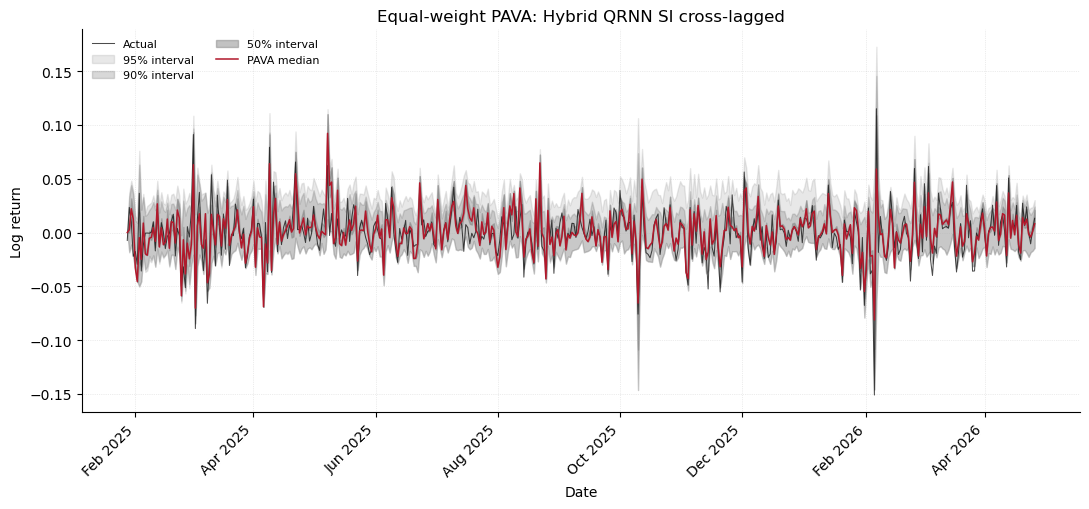


PAVA RESULTS — Hybrid QRNN SI cross-lagged
     level      sigma     raw_nll    pava_nll  raw_pinball  pava_pinball    raw_hre   pava_hre  mean_absolute_adjustment  maximum_absolute_adjustment  changed_forecasts
0.02500000 0.00157255 -2.15723656 -2.21823932   0.00091778    0.00082185 0.05870044 0.03006608                0.00161216                   0.00527554                401
0.05000000 0.00228972 -2.45117886 -2.44696240   0.00133060    0.00134026 0.00374449 0.00506608                0.00161396                   0.00527554                402
0.25000000 0.00745969 -2.55945023 -2.59906414   0.00495931    0.00466381 0.26762115 0.21696035                0.00096044                   0.00854089                218
0.50000000 0.00924071 -2.74347025 -2.75392413   0.00512279    0.00502619 0.00660793 0.02643172                0.00091835                   0.00775507                238
0.75000000 0.00730688 -2.71661696 -2.72922516   0.00386056    0.00376843 0.02092511 0.01651982                0

In [17]:
# ============================================================
# EQUAL-WEIGHT PAVA — HYBRID QRNN SI CROSS-LAGGED
# Uses raw forecasts saved by Sorting; no fitting or tuning
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pava_levels = np.array([0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975], dtype=float)
sorting_dir = Path("sorting_crossover_results/qrnn_si_cross")
prediction_file = sorting_dir / "sorting_qrnn_si_cross_test_predictions.csv"
pava_dir = Path("pava_crossover_results/qrnn_si_cross")
pava_dir.mkdir(parents=True, exist_ok=True)

if not prediction_file.exists():
    raise FileNotFoundError(f"Run Sorting first; missing: {prediction_file}")

data = pd.read_csv(prediction_file)
raw_columns = [column for column in data.columns if column.startswith("Raw_")]
if len(raw_columns) != 7:
    raise RuntimeError(f"Expected 7 raw forecast columns, found {len(raw_columns)}: {raw_columns}")

raw_matrix = data[raw_columns].to_numpy(dtype=float)
actual = data["Actual"].to_numpy(dtype=float)
dates = pd.to_datetime(data["Date"]) if "Date" in data.columns else np.arange(len(data))

# Recover the fitted scale attached to each originally selected trial.
scales = {}
for level in pava_levels:
    ranking_path = Path("qrnn_si_cross_ranking_alpha_{level}.csv".replace("{level}", str(float(level))))
    if not ranking_path.exists():
        raise FileNotFoundError(f"Missing ranking file: {ranking_path}")
    ranking = pd.read_csv(ranking_path)
    order = [column for column in ["sum_rank", "nll", "crp_penalty", "trial"] if column in ranking.columns]
    selected = ranking.sort_values(order).reset_index(drop=True).iloc[0]
    scales[float(level)] = float(selected["sigma"])

def equal_weight_pava(values):
    """Euclidean isotonic projection via pool-adjacent-violators."""
    blocks = []
    for position, value in enumerate(np.asarray(values, dtype=float)):
        blocks.append([float(value), 1, position, position])
        while len(blocks) >= 2 and blocks[-2][0] > blocks[-1][0]:
            right = blocks.pop()
            left = blocks.pop()
            weight = left[1] + right[1]
            mean = (left[0] * left[1] + right[0] * right[1]) / weight
            blocks.append([mean, weight, left[2], right[3]])
    projected = np.empty(len(values), dtype=float)
    for mean, weight, start, end in blocks:
        projected[start:end + 1] = mean
    return projected

pava_matrix = np.vstack([equal_weight_pava(row) for row in raw_matrix])
if np.any(np.diff(pava_matrix, axis=1) < -1e-12):
    raise RuntimeError("PAVA failed to produce a nondecreasing sequence.")

def model_nll(actual, forecast, scale, level):
    residual = actual - forecast
    indicator = (residual < 0).astype(float)
    check = residual * (level - indicator)
    return float(np.mean(-np.log(level * (1.0 - level)) + np.log(scale) + check / scale))

def calibration_metric(actual, forecast, level):
    return float(abs(np.mean(actual < forecast) - level))

def forecast_score(actual, forecast, level):
    residual = actual - forecast
    return float(np.mean(np.maximum(level * residual, (level - 1.0) * residual)))

def crossover_table(matrix, forecast_type):
    rows = []
    for index in range(len(pava_levels) - 1):
        violations = matrix[:, index] > matrix[:, index + 1]
        rows.append({
            "forecast_type": forecast_type,
            "lower_level": pava_levels[index],
            "upper_level": pava_levels[index + 1],
            "violations": int(violations.sum()),
            "violation_rate": float(violations.mean()),
            "tail_pair": index in (0, len(pava_levels) - 2),
        })
    return pd.DataFrame(rows)

metric_rows = []
for index, level in enumerate(pava_levels):
    raw = raw_matrix[:, index]
    adjusted = pava_matrix[:, index]
    change = np.abs(adjusted - raw)
    metric_rows.append({
        "level": level,
        "sigma": scales[float(level)],
        "raw_nll": model_nll(actual, raw, scales[float(level)], level),
        "pava_nll": model_nll(actual, adjusted, scales[float(level)], level),
        "raw_pinball": forecast_score(actual, raw, level),
        "pava_pinball": forecast_score(actual, adjusted, level),
        "raw_hre": calibration_metric(actual, raw, level),
        "pava_hre": calibration_metric(actual, adjusted, level),
        "mean_absolute_adjustment": float(change.mean()),
        "maximum_absolute_adjustment": float(change.max()),
        "changed_forecasts": int((change > 1e-12).sum()),
    })

metrics = pd.DataFrame(metric_rows)
raw_cross = crossover_table(raw_matrix, "Unconstrained")
pava_cross = crossover_table(pava_matrix, "PAVA")
crossovers = pd.concat([raw_cross, pava_cross], ignore_index=True)
raw_total = int(raw_cross["violations"].sum())
pava_total = int(pava_cross["violations"].sum())
raw_tail = int(raw_cross.loc[raw_cross["tail_pair"], "violations"].sum())
pava_tail = int(pava_cross.loc[pava_cross["tail_pair"], "violations"].sum())
changes = np.abs(pava_matrix - raw_matrix)
changed_observations = int(np.any(changes > 1e-12, axis=1).sum())

summary = pd.DataFrame([{
    "model": "Hybrid QRNN SI cross-lagged", "method": "Equal-weight PAVA", "test_T": len(actual),
    "raw_average_nll": metrics["raw_nll"].mean(),
    "pava_average_nll": metrics["pava_nll"].mean(),
    "raw_average_hre": metrics["raw_hre"].mean(),
    "pava_average_hre": metrics["pava_hre"].mean(),
    "raw_total_pinball": metrics["raw_pinball"].sum(),
    "pava_total_pinball": metrics["pava_pinball"].sum(),
    "raw_crossover": raw_total, "pava_crossover": pava_total,
    "raw_tail": raw_tail, "pava_tail": pava_tail,
    "changed_observations": changed_observations,
    "mean_absolute_adjustment": changes.mean(),
    "maximum_absolute_adjustment": changes.max(),
}])

predictions = pd.DataFrame({"Date": dates, "Actual": actual})
for index, level in enumerate(pava_levels):
    tag = f"{level:.3f}".replace(".", "")
    predictions[f"Raw_{tag}"] = raw_matrix[:, index]
    predictions[f"PAVA_{tag}"] = pava_matrix[:, index]

metrics.to_csv(pava_dir / "pava_qrnn_si_cross_test_metrics.csv", index=False)
crossovers.to_csv(pava_dir / "pava_qrnn_si_cross_crossover.csv", index=False)
summary.to_csv(pava_dir / "pava_qrnn_si_cross_summary.csv", index=False)
predictions.to_csv(pava_dir / "pava_qrnn_si_cross_test_predictions.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(dates, actual, color="black", linewidth=0.75, alpha=0.70, label="Actual")
ax.fill_between(dates, pava_matrix[:, 0], pava_matrix[:, 6], color="grey", alpha=0.18, label="95% interval")
ax.fill_between(dates, pava_matrix[:, 1], pava_matrix[:, 5], color="grey", alpha=0.30, label="90% interval")
ax.fill_between(dates, pava_matrix[:, 2], pava_matrix[:, 4], color="grey", alpha=0.48, label="50% interval")
ax.plot(dates, pava_matrix[:, 3], color="#B2182B", linewidth=1.1, label="PAVA median")
ax.set(title="Equal-weight PAVA: Hybrid QRNN SI cross-lagged", xlabel="Date", ylabel="Log return")
if "Date" in data.columns:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")
fig.tight_layout()
plot_path = pava_dir / "pava_qrnn_si_cross_predictions.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 78)
print("PAVA RESULTS — Hybrid QRNN SI cross-lagged")
print("=" * 78)
print(metrics.to_string(index=False, float_format=lambda value: f"{value:.8f}"))
print(f"\nRaw / PAVA average NLL: {metrics['raw_nll'].mean():.6f} / {metrics['pava_nll'].mean():.6f}")
print(f"Raw / PAVA average HRE: {metrics['raw_hre'].mean():.8f} / {metrics['pava_hre'].mean():.8f}")
print(f"Raw / PAVA total pinball: {metrics['raw_pinball'].sum():.8f} / {metrics['pava_pinball'].sum():.8f}")
print(f"Raw crossover / tail: {raw_total} / {raw_tail}")
print(f"PAVA crossover / tail: {pava_total} / {pava_tail}")
print(f"Changed observations: {changed_observations}/{len(actual)}")
print(f"Mean / maximum adjustment: {changes.mean():.8f} / {changes.max():.8f}")
print(f"Results saved under: {pava_dir}")


# Cross Over dealing

In [23]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# Joint QRNN SI Cross-lagged
# One model jointly estimates all seven quantile levels
# ============================================================

alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
alpha_tensor = torch.tensor(alpha_levels, dtype=torch.float32)


class HybridQRNN_SI_Cross_Joint(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(alpha_levels)
        self.eps = 1e-6

        # Seven level-specific parameter sets.
        # Initial values match the original single-level model.
        self.beta1_raw = nn.Parameter(torch.full((self.n_levels,), 1.386))
        self.beta2_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.beta3_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.psi_raw   = nn.Parameter(torch.zeros(self.n_levels))
        self.sigma_raw = nn.Parameter(torch.full((self.n_levels,), 0.5))

        # Shared FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            prev_dim = hidden_dim

        # Output:
        # [median, delta12_raw, delta23_raw, delta34_raw,
        #          delta45_raw, delta56_raw, delta67_raw]
        layers.append(nn.Linear(prev_dim, self.n_levels))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu':  nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def reconstruct_fnn_quantiles(self, raw_fnn):
        """
        raw_fnn shape: (T, 7)

        The first output is the median.
        The remaining six outputs become positive adjacent spacings.
        """
        median = raw_fnn[:, 0]
        delta  = F.softplus(raw_fnn[:, 1:]) + self.eps

        f4 = median

        f3 = f4 - delta[:, 2]
        f2 = f3 - delta[:, 1]
        f1 = f2 - delta[:, 0]

        f5 = f4 + delta[:, 3]
        f6 = f5 + delta[:, 4]
        f7 = f6 + delta[:, 5]

        fnn_quantiles = torch.stack(
            [f1, f2, f3, f4, f5, f6, f7],
            dim=1
        )

        return fnn_quantiles

    def forward(self, y, X, initial_hybrid=None, initial_y=None):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        beta3 = F.softplus(self.beta3_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        # One shared FNN pass gives all seven neural quantiles.
        raw_fnn       = self.fnn(X)
        fnn_quantiles = self.reconstruct_fnn_quantiles(raw_fnn)

        q_hybrid, q_caviar = compute_hybrid_location_cross_si_joint(
            y=y,
            fnn_quantiles=fnn_quantiles,
            beta1=beta1,
            beta2=beta2,
            beta3=beta3,
            psi=psi,
            initial_hybrid=initial_hybrid,
            initial_y=initial_y
        )

        return q_hybrid, sigma, q_caviar, fnn_quantiles


def compute_hybrid_location_cross_si_joint(
    y,
    fnn_quantiles,
    beta1,
    beta2,
    beta3,
    psi,
    initial_hybrid=None,
    initial_y=None
):
    """
    Joint cross-lagged Hybrid QRNN location -- SI form.

    The CaViaR component uses the previous final hybrid output:

        q^S_{k,t}
        = beta1_k q^H_{k,t-1}
        + beta2_k |y_{t-1}|
        + beta3_k q^H_{k,t-1}|y_{t-1}|

    The final hybrid output is:

        q^H_{k,t}
        = psi_k q^S_{k,t}
        + (1-psi_k) f_{k,t}

    All seven levels are updated together at each time step.
    """
    T        = len(y)
    n_levels = fnn_quantiles.shape[1]
    zero_row = y.new_zeros(n_levels)

    q_caviar_list = []
    q_hybrid_list = []

    has_initial_state = (
        initial_hybrid is not None and
        initial_y is not None
    )

    if (initial_hybrid is None) != (initial_y is None):
        raise ValueError(
            "initial_hybrid and initial_y must be supplied together."
        )

    previous_hybrid = (
        initial_hybrid if has_initial_state else zero_row
    )

    for t in range(T):

        # Training sample has no preceding state for t=0.
        # This initial row is excluded from the training loss.
        if t == 0 and not has_initial_state:
            q_caviar_list.append(zero_row)
            q_hybrid_list.append(zero_row)
            continue

        previous_y = initial_y if t == 0 else y[t-1]

        abs_y = torch.abs(previous_y)

        caviar_t = (
            beta1 * previous_hybrid
            + beta2 * abs_y
            + beta3 * previous_hybrid * abs_y
        )

        hybrid_t = (
            psi * caviar_t
            + (1 - psi) * fnn_quantiles[t]
        )

        q_caviar_list.append(caviar_t)
        q_hybrid_list.append(hybrid_t)

        # Cross-lagged: next step uses previous final hybrid output.
        previous_hybrid = hybrid_t

    q_caviar = torch.stack(q_caviar_list, dim=0)
    q_hybrid = torch.stack(q_hybrid_list, dim=0)

    return q_hybrid, q_caviar


# ============================================================
# Joint ALD NLL, HRE and crossover diagnostic
# ============================================================

def hybrid_qrnn_joint_loss(
    y,
    q_hybrid,
    sigma_al,
    alpha_values=alpha_levels
):
    """
    Joint Hybrid QRNN ALD NLL.

    y        : shape (T,)
    q_hybrid : shape (T, 7)
    sigma_al : shape (7,)

    Returns the average NLL across time and all seven levels.
    """
    alpha = torch.tensor(
        alpha_values,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    u         = y.unsqueeze(1) - q_hybrid
    indicator = (u < 0).float()
    rho_alpha = u * (alpha.unsqueeze(0) - indicator)

    nll = (
        -torch.log(alpha * (1 - alpha)).unsqueeze(0)
        + torch.log(sigma_al).unsqueeze(0)
        + rho_alpha / sigma_al.unsqueeze(0)
    )

    return nll.mean()


def compute_hre_joint(
    y,
    q_hybrid,
    alpha_values=alpha_levels
):
    """
    HRE_k = | empirical coverage_k - alpha_k |

    Returns:
        hre_by_level : shape (7,)
        mean_hre     : scalar
    """
    alpha = torch.tensor(
        alpha_values,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    empirical_coverage = (
        y.unsqueeze(1) <= q_hybrid
    ).float().mean(dim=0)

    hre_by_level = torch.abs(empirical_coverage - alpha)
    mean_hre     = hre_by_level.mean()

    return hre_by_level, mean_hre


def compute_crossover_joint(q_hybrid):
    """
    Crossover is a diagnostic only.
    It is not added to the training loss.
    """
    violations = q_hybrid[:, :-1] > q_hybrid[:, 1:]

    pair_counts = violations.sum(dim=0)
    T           = q_hybrid.shape[0]

    total_count = int(pair_counts.sum().item())
    total_rate  = total_count / (T * 6)

    tail_count = int(
        pair_counts[0].item() +
        pair_counts[-1].item()
    )
    tail_rate = tail_count / (T * 2)

    return {
        'pair_counts': [
            int(x) for x in pair_counts.tolist()
        ],
        'total_count': total_count,
        'total_rate':  total_rate,
        'tail_count':  tail_count,
        'tail_rate':   tail_rate
    }


# ============================================================
# Model fitting used inside each Optuna trial
# ============================================================

def fit_joint_qrnn_si_cross(
    config,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = HybridQRNN_SI_Cross_Joint(
        input_dim=X_train.shape[1],
        config=config
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        q_train, sigma_train, _, _ = model(
            y_train,
            X_train
        )

        # Exclude t=0 because it is only an initialisation row.
        train_loss = hybrid_qrnn_joint_loss(
            y_train[1:],
            q_train[1:],
            sigma_train
        )

        if torch.isnan(train_loss) or torch.isinf(train_loss):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        # Validation continues from the final training state.
        model.eval()
        with torch.no_grad():
            q_train_state, sigma_val, _, _ = model(
                y_train,
                X_train
            )

            q_val, _, _, _ = model(
                y_val,
                X_val,
                initial_hybrid=q_train_state[-1],
                initial_y=y_train[-1]
            )

            val_loss = hybrid_qrnn_joint_loss(
                y_val,
                q_val,
                sigma_val
            )

        scheduler.step(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
        else:
            patience_counter += 1

            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    return model


def evaluate_joint_qrnn_si_cross(model):
    model.eval()

    with torch.no_grad():
        q_train, sigma_val, _, _ = model(
            y_train,
            X_train
        )

        q_val, _, _, fnn_val = model(
            y_val,
            X_val,
            initial_hybrid=q_train[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_qrnn_joint_loss(
            y_val,
            q_val,
            sigma_val
        ).item()

        hre_levels, mean_hre = compute_hre_joint(
            y_val,
            q_val
        )

        final_crossover = compute_crossover_joint(q_val)
        fnn_crossover   = compute_crossover_joint(fnn_val)

        beta1 = torch.sigmoid(model.beta1_raw)
        beta2 = F.softplus(model.beta2_raw)
        beta3 = F.softplus(model.beta3_raw)
        psi   = torch.sigmoid(model.psi_raw)
        sigma = F.softplus(model.sigma_raw) + model.eps

    return {
        'mean_nll':         mean_nll,
        'hre_by_level':     hre_levels.tolist(),
        'mean_hre':         mean_hre.item(),
        'final_crossover':  final_crossover,
        'fnn_crossover':    fnn_crossover,
        'beta1':            beta1.tolist(),
        'beta2':            beta2.tolist(),
        'beta3':            beta3.tolist(),
        'psi':              psi.tolist(),
        'sigma':            sigma.tolist()
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_qrnn_si_cross_joint(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation',
            ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float(
            'dropout', 0.0, 0.5
        ),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float(
            'lr', 1e-4, 5e-2, log=True
        ),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}',
            32,
            256
        )

    model = fit_joint_qrnn_si_cross(
        config=config,
        max_epochs=200,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_qrnn_si_cross(model)

    trial.set_user_attr(
        'mean_nll',
        metrics['mean_nll']
    )
    trial.set_user_attr(
        'mean_hre',
        metrics['mean_hre']
    )
    trial.set_user_attr(
        'hre_by_level',
        metrics['hre_by_level']
    )

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )
    trial.set_user_attr(
        'fnn_crossover_count',
        metrics['fnn_crossover']['total_count']
    )

    trial.set_user_attr('beta1', metrics['beta1'])
    trial.set_user_attr('beta2', metrics['beta2'])
    trial.set_user_attr('beta3', metrics['beta3'])
    trial.set_user_attr('psi',   metrics['psi'])
    trial.set_user_attr('sigma', metrics['sigma'])

    print(
        f"Trial {trial.number}: "
        f"Mean NLL={metrics['mean_nll']:.6f} | "
        f"Mean HRE={metrics['mean_hre']:.6f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%} | "
        f"FNN crossover="
        f"{metrics['fnn_crossover']['total_rate']:.2%}"
    )

    # Optuna requires one scalar objective.
    # Final model selection below uses NLL rank + HRE rank.
    return metrics['mean_nll']


# ============================================================
# Rank trials using Mean NLL rank + Mean HRE rank
# ============================================================

def select_best_trial_by_rank_joint(study):
    trials = [
        t for t in study.trials
        if t.state == optuna.trial.TrialState.COMPLETE
        and t.value is not None
        and np.isfinite(t.value)
        and 'mean_nll' in t.user_attrs
        and 'mean_hre' in t.user_attrs
    ]

    if len(trials) == 0:
        raise RuntimeError(
            "No valid completed Optuna trials."
        )

    for t in trials:
        t._nll = t.user_attrs['mean_nll']
        t._hre = t.user_attrs['mean_hre']

    for rank, t in enumerate(
        sorted(trials, key=lambda x: x._nll),
        start=1
    ):
        t._rank_nll = rank

    for rank, t in enumerate(
        sorted(trials, key=lambda x: x._hre),
        start=1
    ):
        t._rank_hre = rank

    best = min(
        trials,
        key=lambda t: (
            t._rank_nll + t._rank_hre,
            t._nll,
            t._hre,
            t.number
        )
    )

    return best, trials


# ============================================================
# Run one joint Optuna study for all seven levels
# ============================================================

base_seed = 2026

print("\n" + "=" * 70)
print("Tuning Joint QRNN SI Cross-lagged for all seven alpha levels")
print("=" * 70)

sampler = TPESampler(seed=base_seed)
study   = optuna.create_study(
    direction='minimize',
    sampler=sampler
)

study.optimize(
    objective_qrnn_si_cross_joint,
    n_trials=800,
    show_progress_bar=True
)

best_trial, all_trials = select_best_trial_by_rank_joint(
    study
)


# ============================================================
# Save full trial ranking
# ============================================================

ranking_records = []

for t in all_trials:
    record = {
        'trial':                  t.number,
        'mean_nll':               t._nll,
        'mean_hre':               t._hre,
        'rank_nll':               t._rank_nll,
        'rank_hre':               t._rank_hre,
        'sum_rank':               t._rank_nll + t._rank_hre,
        'final_crossover_count':  t.user_attrs[
            'final_crossover_count'
        ],
        'final_crossover_rate':   t.user_attrs[
            'final_crossover_rate'
        ],
        'tail_crossover_count':   t.user_attrs[
            'tail_crossover_count'
        ],
        'tail_crossover_rate':    t.user_attrs[
            'tail_crossover_rate'
        ],
        'fnn_crossover_count':    t.user_attrs[
            'fnn_crossover_count'
        ]
    }

    for k, alpha in enumerate(alpha_levels):
        suffix = f'alpha_{alpha}'

        record[f'hre_{suffix}'] = (
            t.user_attrs['hre_by_level'][k]
        )
        record[f'beta1_{suffix}'] = (
            t.user_attrs['beta1'][k]
        )
        record[f'beta2_{suffix}'] = (
            t.user_attrs['beta2'][k]
        )
        record[f'beta3_{suffix}'] = (
            t.user_attrs['beta3'][k]
        )
        record[f'psi_{suffix}'] = (
            t.user_attrs['psi'][k]
        )
        record[f'sigma_{suffix}'] = (
            t.user_attrs['sigma'][k]
        )

    record.update(t.params)
    ranking_records.append(record)


ranking_df = pd.DataFrame(ranking_records)
ranking_df = ranking_df.sort_values(
    ['sum_rank', 'mean_nll', 'mean_hre']
)

ranking_df.to_csv(
    'joint_qrnn_si_cross_ranking.csv',
    index=False
)


# ============================================================
# Refit the selected configuration
# ============================================================

best_config_si_cross = best_trial.params.copy()

best_model_si_cross_joint = fit_joint_qrnn_si_cross(
    config=best_config_si_cross,
    max_epochs=200,
    seed=2026
)

best_metrics_si_cross_joint = evaluate_joint_qrnn_si_cross(
    best_model_si_cross_joint
)


# Save selected model
torch.save(
    {
        'model_state_dict': best_model_si_cross_joint.state_dict(),
        'config':           best_config_si_cross,
        'alpha_levels':     alpha_levels,
        'validation_metrics': best_metrics_si_cross_joint
    },
    'joint_qrnn_si_cross_best.pt'
)


# ============================================================
# Final summary
# ============================================================

print("\n" + "=" * 70)
print("TUNING COMPLETE -- JOINT QRNN SI CROSS-LAGGED")
print("=" * 70)

print(f"Best trial: #{best_trial.number}")
print(
    f"NLL rank: {best_trial._rank_nll} | "
    f"HRE rank: {best_trial._rank_hre} | "
    f"Sum rank: "
    f"{best_trial._rank_nll + best_trial._rank_hre}"
)

print(
    f"Mean validation NLL: "
    f"{best_metrics_si_cross_joint['mean_nll']:.6f}"
)
print(
    f"Mean validation HRE: "
    f"{best_metrics_si_cross_joint['mean_hre']:.6f}"
)

print("\nHRE by alpha:")
for alpha, hre in zip(
    alpha_levels,
    best_metrics_si_cross_joint['hre_by_level']
):
    print(f"  alpha={alpha:.3f}: HRE={hre:.6f}")

print(
    "\nFinal hybrid crossover: "
    f"{best_metrics_si_cross_joint['final_crossover']['total_count']} "
    f"({best_metrics_si_cross_joint['final_crossover']['total_rate']:.2%})"
)

print(
    "Tail crossover: "
    f"{best_metrics_si_cross_joint['final_crossover']['tail_count']} "
    f"({best_metrics_si_cross_joint['final_crossover']['tail_rate']:.2%})"
)

print(
    "FNN crossover count: "
    f"{best_metrics_si_cross_joint['fnn_crossover']['total_count']}"
)

print("\nEstimated parameters by level:")
for k, alpha in enumerate(alpha_levels):
    print(
        f"  alpha={alpha:.3f} | "
        f"beta1={best_metrics_si_cross_joint['beta1'][k]:.4f} | "
        f"beta2={best_metrics_si_cross_joint['beta2'][k]:.4f} | "
        f"beta3={best_metrics_si_cross_joint['beta3'][k]:.4f} | "
        f"psi={best_metrics_si_cross_joint['psi'][k]:.4f} | "
        f"sigma={best_metrics_si_cross_joint['sigma'][k]:.4f}"
    )

print(f"\nBest hyperparameters: {best_config_si_cross}")
print(
    "Full ranking saved to: "
    "joint_qrnn_si_cross_ranking.csv"
)
print(
    "Best model saved to: "
    "joint_qrnn_si_cross_best.pt"
)

[I 2026-07-27 13:42:56,015] A new study created in memory with name: no-name-329fae27-ea75-40dd-8f32-b168446e4fab



Tuning Joint QRNN SI Cross-lagged for all seven alpha levels


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: Mean NLL=2.514233 | Mean HRE=0.065421 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-27 13:43:30,744] Trial 0 finished with value: 2.514233112335205 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 2.514233112335205.
Trial 1: Mean NLL=1.474506 | Mean HRE=0.113056 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-27 13:44:02,014] Trial 1 finished with value: 1.4745062589645386 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 1.4745062589645386.
Trial

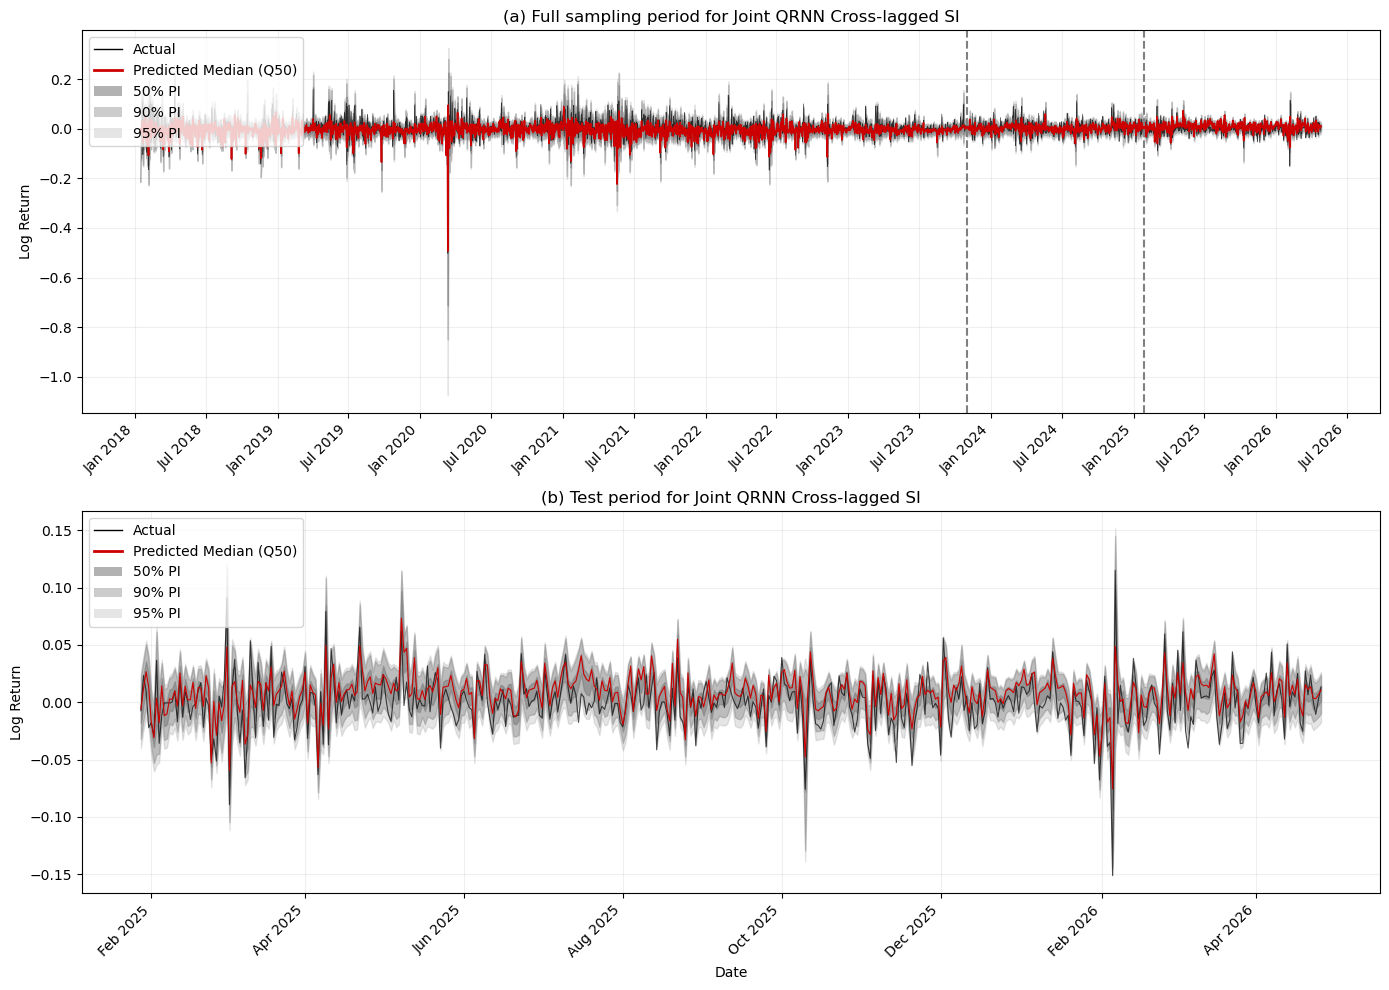

Plot saved to hybrid_qrnn_cross_si_joint_predictions.png

TEST METRICS -- JOINT QRNN SI CROSS-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -2.469146  0.024229 0.000771
 0.050 -2.503801  0.112335 0.062335
 0.250 -2.630277  0.460352 0.210352
 0.500 -2.602596  0.777533 0.277533
 0.750 -2.647932  0.885463 0.135463
 0.950 -2.439876  0.964758 0.014758
 0.975 -2.362597  0.982379 0.007379

Average NLL: -2.522318
Average HRE: 0.101227

CROSSOVER ANALYSIS -- FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 20 (4.41%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 20 (0.73%)
Tail violations: 0 (0.00%)

CROSSOVER ANALYSIS -- MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)


In [25]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# Joint QRNN SI Cross-lagged -- plotting and test evaluation
# Run directly after the joint tuning code
# ============================================================

X_test_q = torch.tensor(
    test_df[feature_cols].values,
    dtype=torch.float32
)
y_test_q = torch.tensor(
    test_df['log_return'].values,
    dtype=torch.float32
)

model = best_model_si_cross_joint
model.eval()


# -------------------------
# Sequential predictions
# -------------------------
with torch.no_grad():
    q_train, sigma, _, fnn_train = model(
        y_train, X_train
    )

    q_val, _, _, fnn_val = model(
        y_val,
        X_val,
        initial_hybrid=q_train[-1],
        initial_y=y_train[-1]
    )

    q_test, _, _, fnn_test = model(
        y_test_q,
        X_test_q,
        initial_hybrid=q_val[-1],
        initial_y=y_val[-1]
    )

q_train_np = q_train.numpy()
q_val_np   = q_val.numpy()
q_test_np  = q_test.numpy()

q_all = np.concatenate(
    [q_train_np, q_val_np, q_test_np],
    axis=0
)

y_all = np.concatenate([
    train_df['log_return'].values,
    val_df['log_return'].values,
    test_df['log_return'].values
])

all_dates = (
    train_df.index
    .append(val_df.index)
    .append(test_df.index)
)

level_index = {
    alpha: k
    for k, alpha in enumerate(alpha_levels)
}

all_preds_qrnn_si_cross = {
    alpha: q_all[:, k]
    for k, alpha in enumerate(alpha_levels)
}


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_qrnn_joint(
    all_preds,
    train_df,
    val_df,
    test_df,
    save_fname='hybrid_qrnn_cross_si_joint_predictions.png'
):
    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    train_size = len(train_df)
    val_size   = len(val_df)
    test_start = train_size + val_size

    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    legend_elements = [
        Line2D(
            [0], [0],
            color=actual_color,
            lw=1,
            label='Actual'
        ),
        Line2D(
            [0], [0],
            color=pred_color,
            lw=2,
            label='Predicted Median (Q50)'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.6,
            label='50% PI'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.4,
            label='90% PI'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.2,
            label='95% PI'
        )
    ]

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 10)
    )

    # -------------------------
    # Full sample
    # -------------------------
    ax = axes[0]

    ax.plot(
        all_dates,
        y_all,
        color=actual_color,
        linewidth=0.5,
        alpha=0.7
    )
    ax.plot(
        all_dates,
        all_preds[0.500],
        color=pred_color,
        linewidth=1.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.025],
        all_preds[0.975],
        color=pi_color,
        alpha=0.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.050],
        all_preds[0.950],
        color=pi_color,
        alpha=0.4
    )
    ax.fill_between(
        all_dates,
        all_preds[0.250],
        all_preds[0.750],
        color=pi_color,
        alpha=0.6
    )

    ax.axvline(
        train_df.index[-1],
        color='gray',
        linestyle='--'
    )
    ax.axvline(
        val_df.index[-1],
        color='gray',
        linestyle='--'
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=6)
    )
    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax.set_title(
        '(a) Full sampling period for '
        'Joint QRNN Cross-lagged SI'
    )
    ax.set_ylabel('Log Return')
    ax.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax.grid(True, alpha=0.2)

    # -------------------------
    # Test sample
    # -------------------------
    ax2 = axes[1]

    ax2.plot(
        test_dates,
        y_test_np,
        color=actual_color,
        linewidth=0.8,
        alpha=0.7
    )
    ax2.plot(
        test_dates,
        all_preds[0.500][test_start:],
        color=pred_color,
        linewidth=0.8
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.025][test_start:],
        all_preds[0.975][test_start:],
        color=pi_color,
        alpha=0.2
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.050][test_start:],
        all_preds[0.950][test_start:],
        color=pi_color,
        alpha=0.4
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.250][test_start:],
        all_preds[0.750][test_start:],
        color=pi_color,
        alpha=0.6
    )

    ax2.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax2.xaxis.set_major_locator(
        mdates.MonthLocator(interval=2)
    )
    plt.setp(
        ax2.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax2.set_title(
        '(b) Test period for '
        'Joint QRNN Cross-lagged SI'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Log Return')
    ax2.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(
        save_fname,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print(f'Plot saved to {save_fname}')


plot_two_panel_qrnn_joint(
    all_preds_qrnn_si_cross,
    train_df,
    val_df,
    test_df
)


# ============================================================
# Test NLL and HRE
# ============================================================
def compute_test_metrics_joint(
    y_test,
    q_test,
    sigma,
    alpha_levels
):
    records = []

    for k, alpha in enumerate(alpha_levels):
        y = y_test
        q = q_test[:, k]
        sigma_k = sigma[k]

        u = y - q
        indicator = (u < 0).float()
        rho = u * (alpha - indicator)

        nll = (
            -np.log(alpha * (1 - alpha))
            + torch.log(sigma_k)
            + rho / sigma_k
        ).mean().item()

        hit_rate = (
            y <= q
        ).float().mean().item()

        hre = abs(hit_rate - alpha)

        records.append({
            'alpha': alpha,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': hre
        })

    results = pd.DataFrame(records)

    print('\n' + '=' * 60)
    print('TEST METRICS -- JOINT QRNN SI CROSS-LAGGED')
    print('=' * 60)
    print(results.to_string(index=False))
    print(f"\nAverage NLL: {results['NLL'].mean():.6f}")
    print(f"Average HRE: {results['HRE'].mean():.6f}")

    results.to_csv(
        'joint_qrnn_si_cross_test_metrics.csv',
        index=False
    )

    return results


test_metrics_qrnn_si_cross = compute_test_metrics_joint(
    y_test_q,
    q_test,
    sigma,
    alpha_levels
)


# ============================================================
# Test crossover analysis
# ============================================================
def compute_crossovers_joint(
    q_pred,
    levels,
    model_name
):
    q = q_pred.numpy()
    T = len(q)

    total_violations = 0
    tail_violations  = 0

    print('\n' + '=' * 60)
    print(f'CROSSOVER ANALYSIS -- {model_name}')
    print('=' * 60)

    for k in range(len(levels) - 1):
        lo = levels[k]
        hi = levels[k + 1]

        violations = int(
            np.sum(q[:, k] > q[:, k + 1])
        )
        percentage = violations / T * 100

        total_violations += violations

        if k == 0 or k == len(levels) - 2:
            tail_violations += violations
            marker = ' <-- TAIL'
        else:
            marker = ''

        print(
            f'({lo:.3f}, {hi:.3f}): '
            f'{violations} ({percentage:.2f}%){marker}'
        )

    total_rate = (
        total_violations /
        (T * (len(levels) - 1))
    )
    tail_rate = tail_violations / (T * 2)

    print(
        f'\nTotal violations: {total_violations} '
        f'({total_rate:.2%})'
    )
    print(
        f'Tail violations: {tail_violations} '
        f'({tail_rate:.2%})'
    )

    return total_violations, tail_violations


# Final hybrid forecasts: crossing may remain
final_crossovers = compute_crossovers_joint(
    q_test,
    alpha_levels,
    'FINAL HYBRID OUTPUT'
)

# FNN forecasts: crossing should be zero
fnn_crossovers = compute_crossovers_joint(
    fnn_test,
    alpha_levels,
    'MONOTONIC FNN OUTPUT'
)

# Cross over dealing 1b


In [16]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 1B -- JOINT QRNN SI Cross-LAGGED
# Complete-output non-crossing through positive adjacent spacing
# ============================================================

M1B_DISTRIBUTION = 'qrnn'   # 'qrnn' or 'ernn'
M1B_FORM = 'si'           # 's' or 'si'
M1B_LAG = 'cross'             # 'self' or 'cross'
M1B_N_TRIALS = 800
M1B_MAX_EPOCHS = 800
M1B_BASE_SEED = 2026

m1b_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
m1b_spacing_names = [
    'delta12', 'delta23', 'delta34',
    'delta45', 'delta56', 'delta67',
]
m1b_model_tag = (
    f'method1b_joint_{M1B_DISTRIBUTION}_{M1B_FORM}_{M1B_LAG}'
)


def m1b_validate_inputs():
    required = ('y_train', 'X_train', 'y_val', 'X_val')
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            'Run the notebook data preparation first. Missing: '
            + ', '.join(missing)
        )

    for y_name, x_name in (
        ('y_train', 'X_train'),
        ('y_val', 'X_val'),
    ):
        y_value = globals()[y_name]
        x_value = globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(
            x_value, torch.Tensor
        ):
            raise TypeError(f'{y_name} and {x_name} must be tensors.')
        if y_value.ndim != 1 or x_value.ndim != 2:
            raise ValueError(f'{y_name} must be (T,) and {x_name} (T,p).')
        if len(y_value) != len(x_value):
            raise ValueError(f'{y_name} and {x_name} lengths differ.')


class Method1BJointHybrid(nn.Module):
    """Central hybrid forecast plus six jointly learned positive gaps."""

    def __init__(self, input_dim, config):
        super().__init__()
        self.eps = 1e-6

        # Identifiable statistical/mixing parameters for the median only.
        self.persistence_raw = nn.Parameter(torch.tensor(1.386))
        self.news1_raw = nn.Parameter(torch.tensor(0.3))
        if M1B_FORM == 'si':
            self.news2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))

        # One loss scale per final level.
        self.sigma_raw = nn.Parameter(torch.full((7,), 0.5))

        layers = []
        previous_dim = input_dim
        for index in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{index}']
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            previous_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.median_head = nn.Linear(previous_dim, 1)
        self.spacing_heads = nn.ModuleDict({
            name: nn.Linear(previous_dim + 1, 1)
            for name in m1b_spacing_names
        })

        for module in self.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    @staticmethod
    def _activation(name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
        }[name]

    def _positive_spacing(self, features, reference, name):
        spacing_input = torch.cat(
            [features, reference.unsqueeze(1)], dim=1
        )
        raw_spacing = self.spacing_heads[name](spacing_input).squeeze(1)
        return F.softplus(raw_spacing) + self.eps

    def _median_recursion(
        self,
        y,
        median_fnn,
        initial_state=None,
        initial_y=None,
    ):
        if (initial_state is None) != (initial_y is None):
            raise ValueError(
                'initial_state and initial_y must be supplied together.'
            )

        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        news2 = (
            F.softplus(self.news2_raw)
            if M1B_FORM == 'si'
            else None
        )
        psi = torch.sigmoid(self.psi_raw)

        has_state = initial_state is not None
        previous_state = (
            initial_state if has_state else y.new_zeros(())
        )

        statistical_values = []
        hybrid_values = []

        for time_index in range(len(y)):
            if time_index == 0 and not has_state:
                zero = y.new_zeros(())
                statistical_values.append(zero)
                hybrid_values.append(zero)
                continue

            previous_y = (
                initial_y if time_index == 0 else y[time_index - 1]
            )
            absolute_return = torch.abs(previous_y)

            statistical = (
                persistence * previous_state
                + news1 * absolute_return
            )
            if M1B_FORM == 'si':
                statistical = (
                    statistical
                    + news2 * previous_state * absolute_return
                )

            hybrid = psi * statistical + (1 - psi) * median_fnn[
                time_index
            ]
            statistical_values.append(statistical)
            hybrid_values.append(hybrid)

            previous_state = (
                statistical if M1B_LAG == 'self' else hybrid
            )

        return (
            torch.stack(hybrid_values),
            torch.stack(statistical_values),
        )

    def forward(
        self,
        y,
        X,
        initial_state=None,
        initial_y=None,
    ):
        features = self.feature_extractor(X)
        median_fnn = self.median_head(features).squeeze(1)
        median, statistical = self._median_recursion(
            y,
            median_fnn,
            initial_state=initial_state,
            initial_y=initial_y,
        )

        # Outward reconstruction; references remain attached so that
        # all seven losses jointly train the median and inner spacings.
        delta34 = self._positive_spacing(features, median, 'delta34')
        level3 = median - delta34
        delta23 = self._positive_spacing(features, level3, 'delta23')
        level2 = level3 - delta23
        delta12 = self._positive_spacing(features, level2, 'delta12')
        level1 = level2 - delta12

        delta45 = self._positive_spacing(features, median, 'delta45')
        level5 = median + delta45
        delta56 = self._positive_spacing(features, level5, 'delta56')
        level6 = level5 + delta56
        delta67 = self._positive_spacing(features, level6, 'delta67')
        level7 = level6 + delta67

        forecasts = torch.stack(
            [level1, level2, level3, median, level5, level6, level7],
            dim=1,
        )
        spacings = torch.stack(
            [delta12, delta23, delta34, delta45, delta56, delta67],
            dim=1,
        )
        sigma = F.softplus(self.sigma_raw) + self.eps
        continuation_state = (
            statistical if M1B_LAG == 'self' else median
        )
        return forecasts, sigma, continuation_state, statistical, median, spacings


def m1b_joint_nll(y, forecasts, sigma):
    levels = forecasts.new_tensor(m1b_levels)
    residual = y.unsqueeze(1) - forecasts

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(forecasts.dtype)
        check_loss = residual * (levels.unsqueeze(0) - indicator)
        nll = (
            -torch.log(levels * (1 - levels)).unsqueeze(0)
            + torch.log(sigma).unsqueeze(0)
            + check_loss / sigma.unsqueeze(0)
        )
    else:
        weight = torch.abs(
            levels.unsqueeze(0)
            - (residual < 0).to(forecasts.dtype)
        )
        constant = (
            torch.log(
                torch.sqrt(torch.pi / levels)
                + torch.sqrt(torch.pi / (1 - levels))
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma).unsqueeze(0)
            + constant.unsqueeze(0)
            + weight * residual.square() / sigma.square().unsqueeze(0)
        )

    return nll.mean()


def m1b_secondary_metric(y, forecasts):
    levels = forecasts.new_tensor(m1b_levels)
    if M1B_DISTRIBUTION == 'qrnn':
        hit_rate = (y.unsqueeze(1) <= forecasts).float().mean(dim=0)
        by_level = torch.abs(hit_rate - levels)
        return by_level, by_level.mean(), hit_rate

    residual = y.unsqueeze(1) - forecasts
    weight = torch.abs(
        levels.unsqueeze(0)
        - (residual < 0).to(forecasts.dtype)
    )
    by_level = (weight * residual.square()).mean(dim=0)
    return by_level, by_level.mean(), None


def m1b_crossover(forecasts):
    violations = forecasts[:, :-1] > forecasts[:, 1:]
    pair_counts = violations.sum(dim=0)
    sample_size = forecasts.shape[0]
    total = int(pair_counts.sum().item())
    tail = int(pair_counts[0].item() + pair_counts[-1].item())
    return {
        'pair_counts': [int(value) for value in pair_counts.tolist()],
        'total_count': total,
        'total_rate': total / (sample_size * 6),
        'tail_count': tail,
        'tail_rate': tail / (sample_size * 2),
    }


def m1b_suggest_config(trial):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        ),
    }
    for index in range(config['n_hidden_layers']):
        config[f'hidden_dim_{index}'] = trial.suggest_int(
            f'hidden_dim_{index}', 32, 256
        )
    return config


def m1b_fit(config, max_epochs=M1B_MAX_EPOCHS, seed=M1B_BASE_SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = Method1BJointHybrid(X_train.shape[1], config)
    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    optimizer = optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    best_loss = float('inf')
    best_state = None
    patience_counter = 0

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        train_forecasts, sigma, _, _, _, _ = model(y_train, X_train)
        train_loss = m1b_joint_nll(
            y_train[1:], train_forecasts[1:], sigma
        )
        if not torch.isfinite(train_loss):
            return None
        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, _, train_state, _, _, _ = model(y_train, X_train)
            validation_forecasts, validation_sigma, _, _, _, _ = model(
                y_val,
                X_val,
                initial_state=train_state[-1],
                initial_y=y_train[-1],
            )
            validation_loss = m1b_joint_nll(
                y_val, validation_forecasts, validation_sigma
            )

        if not torch.isfinite(validation_loss):
            return None
        scheduler.step(validation_loss.item())
        if validation_loss.item() < best_loss:
            best_loss = validation_loss.item()
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def m1b_evaluate(model):
    model.eval()
    with torch.no_grad():
        _, _, train_state, _, _, _ = model(y_train, X_train)
        forecasts, sigma, _, _, _, spacings = model(
            y_val,
            X_val,
            initial_state=train_state[-1],
            initial_y=y_train[-1],
        )
        mean_nll = m1b_joint_nll(y_val, forecasts, sigma).item()
        by_level, secondary, hit_rate = m1b_secondary_metric(
            y_val, forecasts
        )

        metrics = {
            'mean_nll': mean_nll,
            'secondary': secondary.item(),
            'secondary_by_level': by_level.tolist(),
            'crossover': m1b_crossover(forecasts),
            'spacing_mean': spacings.mean(dim=0).tolist(),
            'spacing_min': spacings.min(dim=0).values.tolist(),
            'spacing_max': spacings.max(dim=0).values.tolist(),
            'spacing_std': spacings.std(
                dim=0, unbiased=False
            ).tolist(),
            'near_zero_count': (
                spacings <= 1e-5
            ).sum(dim=0).tolist(),
            'persistence': torch.sigmoid(
                model.persistence_raw
            ).item(),
            'news1': F.softplus(model.news1_raw).item(),
            'news2': (
                F.softplus(model.news2_raw).item()
                if M1B_FORM == 'si'
                else np.nan
            ),
            'psi': torch.sigmoid(model.psi_raw).item(),
            'sigma': (
                F.softplus(model.sigma_raw) + model.eps
            ).tolist(),
        }
        if hit_rate is not None:
            metrics['hit_rate'] = hit_rate.tolist()
        return metrics


def m1b_objective(trial):
    config = m1b_suggest_config(trial)
    model = m1b_fit(config)
    if model is None:
        return float('inf')
    metrics = m1b_evaluate(model)
    for name, value in metrics.items():
        trial.set_user_attr(name, value)
    metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
    print(
        f"Trial {trial.number}: NLL={metrics['mean_nll']:.6f} | "
        f"{metric_name}={metrics['secondary']:.8f} | "
        f"crossover={metrics['crossover']['total_rate']:.2%}"
    )
    return metrics['mean_nll']


def m1b_select_by_rank(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'mean_nll' in trial.user_attrs
        and 'secondary' in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError('No valid Method 1b trials.')

    nll_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['mean_nll'], trial.number),
    )
    secondary_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['secondary'], trial.number),
    )
    rank_nll = {
        trial.number: rank
        for rank, trial in enumerate(nll_order, 1)
    }
    rank_secondary = {
        trial.number: rank
        for rank, trial in enumerate(secondary_order, 1)
    }
    best = min(
        trials,
        key=lambda trial: (
            rank_nll[trial.number] + rank_secondary[trial.number],
            trial.user_attrs['mean_nll'],
            trial.user_attrs['secondary'],
            trial.number,
        ),
    )
    return best, trials, rank_nll, rank_secondary


m1b_validate_inputs()
print('\n' + '=' * 72)
print(
    f'Tuning Method 1b Joint {M1B_DISTRIBUTION.upper()} '
    f'{M1B_FORM.upper()} {M1B_LAG.title()}-lagged'
)
print('=' * 72)

m1b_study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=M1B_BASE_SEED),
)
m1b_study.optimize(
    m1b_objective,
    n_trials=M1B_N_TRIALS,
    show_progress_bar=True,
)

(
    m1b_best_trial,
    m1b_all_trials,
    m1b_rank_nll,
    m1b_rank_secondary,
) = m1b_select_by_rank(m1b_study)

m1b_ranking_records = []
for trial in m1b_all_trials:
    record = {
        'trial': trial.number,
        'mean_nll': trial.user_attrs['mean_nll'],
        ('mean_hre' if M1B_DISTRIBUTION == 'qrnn' else 'mean_ase'):
            trial.user_attrs['secondary'],
        'rank_nll': m1b_rank_nll[trial.number],
        'rank_secondary': m1b_rank_secondary[trial.number],
        'sum_rank': (
            m1b_rank_nll[trial.number]
            + m1b_rank_secondary[trial.number]
        ),
        'crossover_count': trial.user_attrs['crossover']['total_count'],
        'crossover_rate': trial.user_attrs['crossover']['total_rate'],
        'tail_count': trial.user_attrs['crossover']['tail_count'],
        'tail_rate': trial.user_attrs['crossover']['tail_rate'],
        'persistence': trial.user_attrs['persistence'],
        'news1': trial.user_attrs['news1'],
        'news2': trial.user_attrs['news2'],
        'psi': trial.user_attrs['psi'],
    }
    for index, level in enumerate(m1b_levels):
        metric_label = 'hre' if M1B_DISTRIBUTION == 'qrnn' else 'ase'
        record[f'{metric_label}_{level:.3f}'] = trial.user_attrs[
            'secondary_by_level'
        ][index]
        record[f'sigma_{level:.3f}'] = trial.user_attrs['sigma'][index]
    record.update(trial.params)
    m1b_ranking_records.append(record)

m1b_ranking_df = pd.DataFrame(m1b_ranking_records).sort_values(
    ['sum_rank', 'mean_nll', 'trial']
)
m1b_ranking_filename = f'{m1b_model_tag}_ranking.csv'
m1b_ranking_df.to_csv(m1b_ranking_filename, index=False)

m1b_best_config = m1b_best_trial.params.copy()
m1b_best_model = m1b_fit(m1b_best_config)
if m1b_best_model is None:
    raise RuntimeError('Selected Method 1b configuration failed to refit.')
m1b_best_metrics = m1b_evaluate(m1b_best_model)

m1b_checkpoint_filename = f'{m1b_model_tag}_best.pt'
torch.save(
    {
        'model_state_dict': m1b_best_model.state_dict(),
        'config': m1b_best_config,
        'levels': m1b_levels,
        'distribution': M1B_DISTRIBUTION,
        'form': M1B_FORM,
        'lag': M1B_LAG,
        'validation_metrics': m1b_best_metrics,
    },
    m1b_checkpoint_filename,
)

m1b_metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
print('\n' + '=' * 72)
print('METHOD 1B TUNING COMPLETE')
print('=' * 72)
print(f'Best trial: #{m1b_best_trial.number}')
print(f"Mean validation NLL: {m1b_best_metrics['mean_nll']:.6f}")
print(
    f"Mean validation {m1b_metric_name}: "
    f"{m1b_best_metrics['secondary']:.8f}"
)
print(
    f"Final crossover: {m1b_best_metrics['crossover']['total_count']} "
    f"({m1b_best_metrics['crossover']['total_rate']:.2%})"
)
print(f'Saved ranking: {m1b_ranking_filename}')
print(f'Saved model: {m1b_checkpoint_filename}')



[I 2026-08-20 11:54:09,843] A new study created in memory with name: no-name-0b6b84f9-baad-4f7c-8f7e-8b62927b7590



Tuning Method 1b Joint QRNN SI Cross-lagged


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=2.215438 | HRE=0.19080731 | crossover=0.00%
[I 2026-08-20 11:56:20,792] Trial 0 finished with value: 2.2154383659362793 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 2.2154383659362793.
Trial 1: NLL=-1.510983 | HRE=0.05550300 | crossover=0.00%
[I 2026-08-20 11:58:31,152] Trial 1 finished with value: -1.5109827518463135 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -1.5109827518463135.
Trial 2: NLL=2.605521 | HRE=0.16176285 | crossover=0.00%
[I 2026-08-20 1

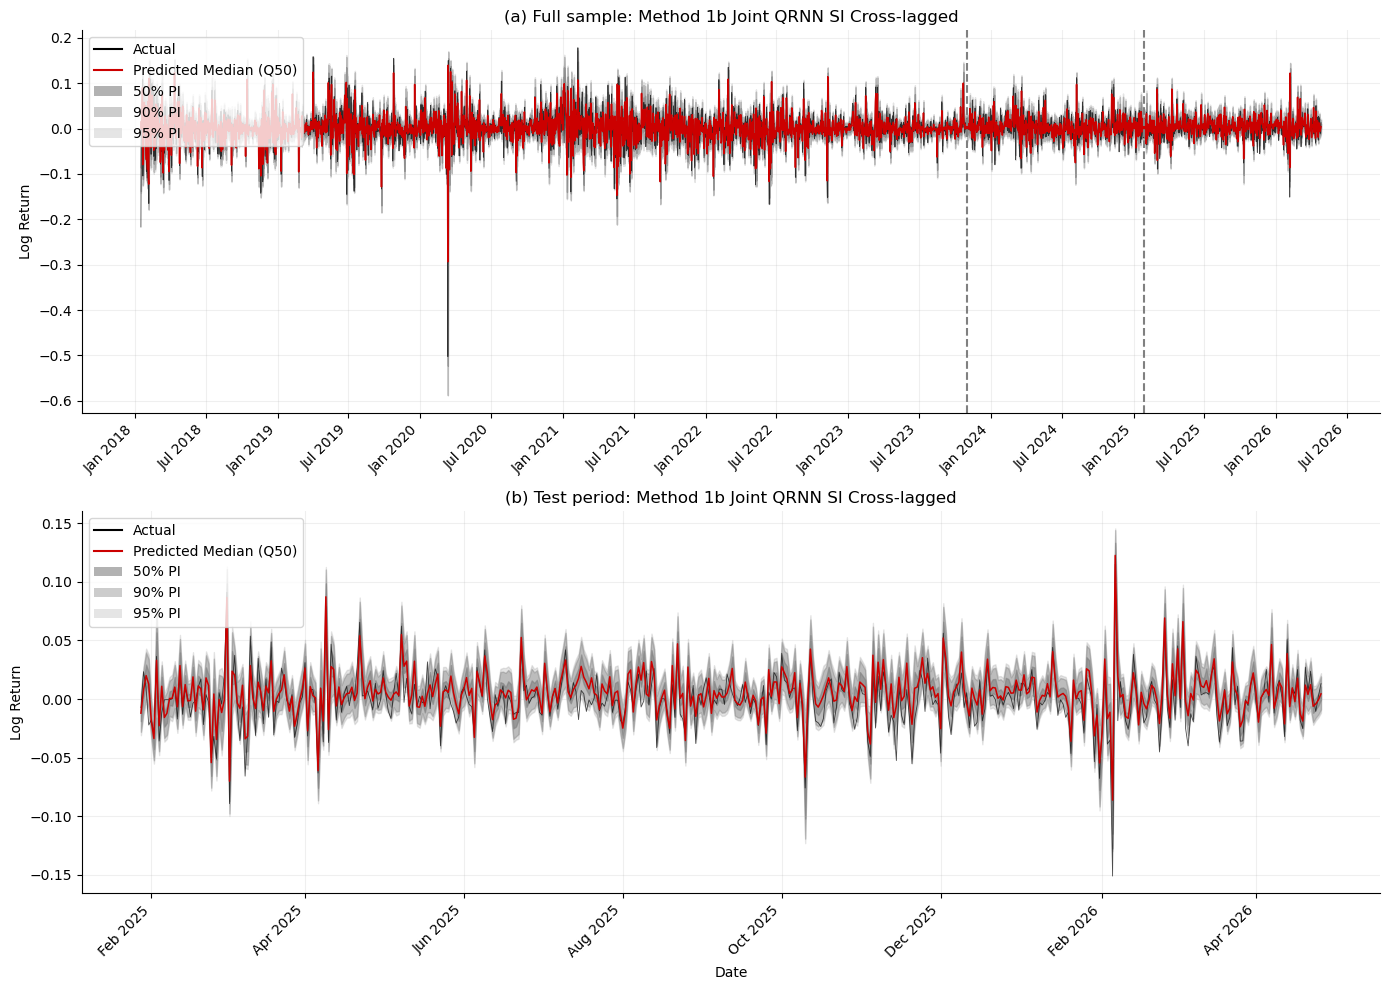

Plot saved to: method1b_joint_qrnn_si_cross_predictions.png

TEST METRICS -- METHOD 1B JOINT QRNN SI CROSS-LAGGED
 level       NLL  Hit_Rate      HRE    sigma
 0.025 -2.432745  0.079295 0.054295 0.001040
 0.050 -2.531037  0.140969 0.090969 0.001786
 0.250 -2.804185  0.464758 0.214758 0.005204
 0.500 -2.882427  0.698238 0.198238 0.006657
 0.750 -2.844458  0.870044 0.120044 0.005184
 0.950 -2.590326  0.980176 0.030176 0.001790
 0.975 -2.480938  0.995595 0.020595 0.001059

Average NLL: -2.652302
Average HRE: 0.10415356

CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS
 Lower  Upper  Violations  Rate
 0.025  0.050           0   0.0
 0.050  0.250           0   0.0
 0.250  0.500           0   0.0
 0.500  0.750           0   0.0
 0.750  0.950           0   0.0
 0.950  0.975           0   0.0

Total violations: 0
Tail violations: 0

LEARNED SPACING DIAGNOSTICS -- TEST PERIOD
Spacing  Lower_Level  Upper_Level  Mean_Delta  Minimum_Delta  Maximum_Delta  Delta_Std  Near_Zero_Count  Near_Zero_Rate
d

In [18]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# PLOT AND EVALUATE METHOD 1B -- QRNN SI
# Cross-LAGGED
# ============================================================

m1b_plot_pairs = list(zip(m1b_levels[:-1], m1b_levels[1:]))
m1b_plot_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

if 'm1b_best_model' not in globals():
    m1b_plot_checkpoint_filename = f'{m1b_model_tag}_best.pt'
    m1b_plot_checkpoint = torch.load(
        m1b_plot_checkpoint_filename,
        map_location='cpu',
        weights_only=False,
    )
    m1b_best_model = Method1BJointHybrid(
        X_train.shape[1], m1b_plot_checkpoint['config']
    )
    m1b_best_model.load_state_dict(
        m1b_plot_checkpoint['model_state_dict']
    )

m1b_best_model.eval()

m1b_plot_X_all = torch.tensor(
    df[feature_cols].values, dtype=torch.float32
)
m1b_plot_y_all = torch.tensor(
    df['log_return'].values, dtype=torch.float32
)

with torch.no_grad():
    (
        m1b_plot_forecasts_all,
        m1b_plot_sigma,
        _,
        _,
        _,
        m1b_plot_spacings_all,
    ) = m1b_best_model(m1b_plot_y_all, m1b_plot_X_all)

m1b_plot_forecasts_np = m1b_plot_forecasts_all.cpu().numpy()
m1b_plot_spacings_np = m1b_plot_spacings_all.cpu().numpy()
m1b_plot_test_start = len(train_df) + len(val_df)
m1b_plot_forecasts_test = m1b_plot_forecasts_all[
    m1b_plot_test_start:
]
m1b_plot_spacings_test = m1b_plot_spacings_all[m1b_plot_test_start:]
m1b_plot_y_test = m1b_plot_y_all[m1b_plot_test_start:]

if len(m1b_plot_forecasts_test) != len(test_df):
    raise ValueError(
        'Test forecast length does not match test_df. Check the split.'
    )


def m1b_draw_panel(axis, dates, actual, forecasts):
    axis.plot(dates, actual, color='#000000', linewidth=0.6, alpha=0.7)
    axis.plot(
        dates, forecasts[:, 3], color='#CC0000', linewidth=1.1
    )
    axis.fill_between(
        dates, forecasts[:, 0], forecasts[:, 6],
        color='#808080', alpha=0.20,
    )
    axis.fill_between(
        dates, forecasts[:, 1], forecasts[:, 5],
        color='#808080', alpha=0.40,
    )
    axis.fill_between(
        dates, forecasts[:, 2], forecasts[:, 4],
        color='#808080', alpha=0.60,
    )
    axis.set_ylabel('Log Return')
    axis.grid(True, alpha=0.2)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


m1b_plot_distribution_label = M1B_DISTRIBUTION.upper()
m1b_plot_form_label = M1B_FORM.upper()
m1b_plot_lag_label = M1B_LAG.title()
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

m1b_draw_panel(
    axes[0], df.index, df['log_return'].values, m1b_plot_forecasts_np
)
axes[0].axvline(train_df.index[-1], color='gray', linestyle='--')
axes[0].axvline(val_df.index[-1], color='gray', linestyle='--')
axes[0].set_title(
    f'(a) Full sample: Method 1b Joint {m1b_plot_distribution_label} '
    f'{m1b_plot_form_label} {m1b_plot_lag_label}-lagged'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m1b_draw_panel(
    axes[1],
    test_df.index,
    test_df['log_return'].values,
    m1b_plot_forecasts_np[m1b_plot_test_start:],
)
axes[1].set_title(
    f'(b) Test period: Method 1b Joint '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label}-lagged'
)
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

if M1B_DISTRIBUTION == 'qrnn':
    median_label = 'Predicted Median (Q50)'
    band_labels = ['50% PI', '90% PI', '95% PI']
else:
    median_label = 'Predicted median expectile'
    band_labels = [
        '0.25--0.75 expectile band',
        '0.05--0.95 expectile band',
        '0.025--0.975 expectile band',
    ]

m1b_legend = [
    Line2D([0], [0], color='#000000', label='Actual'),
    Line2D([0], [0], color='#CC0000', label=median_label),
    Patch(facecolor='#808080', alpha=0.60, label=band_labels[0]),
    Patch(facecolor='#808080', alpha=0.40, label=band_labels[1]),
    Patch(facecolor='#808080', alpha=0.20, label=band_labels[2]),
]
for axis in axes:
    axis.legend(handles=m1b_legend, loc='upper left')
    plt.setp(
        axis.xaxis.get_majorticklabels(), rotation=45, ha='right'
    )

plt.tight_layout()
m1b_plot_png = f'{m1b_model_tag}_predictions.png'
plt.savefig(m1b_plot_png, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f'Plot saved to: {m1b_plot_png}')


# ============================================================
# Test metrics by level
# ============================================================

m1b_plot_metric_rows = []
for index, level in enumerate(m1b_levels):
    forecast = m1b_plot_forecasts_test[:, index]
    sigma = m1b_plot_sigma[index]
    residual = m1b_plot_y_test - forecast

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(residual.dtype)
        check_loss = residual * (level - indicator)
        nll = (
            -torch.log(residual.new_tensor(level * (1 - level)))
            + torch.log(sigma)
            + check_loss / sigma
        ).mean().item()
        hit_rate = (
            m1b_plot_y_test <= forecast
        ).float().mean().item()
        secondary = abs(hit_rate - level)
        row = {
            'level': level,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': secondary,
            'sigma': sigma.item(),
        }
    else:
        weight = torch.abs(
            residual.new_tensor(level)
            - (residual < 0).to(residual.dtype)
        )
        weighted_squared_error = weight * residual.square()
        constant = (
            torch.log(
                torch.sqrt(residual.new_tensor(torch.pi / level))
                + torch.sqrt(
                    residual.new_tensor(torch.pi / (1 - level))
                )
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma)
            + constant
            + weighted_squared_error / sigma.square()
        ).mean().item()
        secondary = weighted_squared_error.mean().item()
        row = {
            'level': level,
            'NLL': nll,
            'ASE': secondary,
            'sigma': sigma.item(),
        }

    m1b_plot_metric_rows.append(row)

m1b_plot_metrics_df = pd.DataFrame(m1b_plot_metric_rows)
m1b_plot_metric_column = (
    'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
)
print('\n' + '=' * 72)
print(
    f'TEST METRICS -- METHOD 1B JOINT '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label.upper()}-LAGGED'
)
print('=' * 72)
print(m1b_plot_metrics_df.to_string(index=False))
print(f"\nAverage NLL: {m1b_plot_metrics_df['NLL'].mean():.6f}")
print(
    f'Average {m1b_plot_metric_column}: '
    f"{m1b_plot_metrics_df[m1b_plot_metric_column].mean():.8f}"
)


# ============================================================
# Crossover and learned-spacing diagnostics
# ============================================================

m1b_plot_crossover_rows = []
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    count = int((
        m1b_plot_forecasts_test[:, index]
        > m1b_plot_forecasts_test[:, index + 1]
    ).sum().item())
    m1b_plot_crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': count,
        'Rate': count / len(m1b_plot_y_test),
    })

m1b_plot_crossover_df = pd.DataFrame(m1b_plot_crossover_rows)
m1b_plot_total = int(m1b_plot_crossover_df['Violations'].sum())
m1b_plot_tail = int(
    m1b_plot_crossover_df.iloc[0]['Violations']
    + m1b_plot_crossover_df.iloc[-1]['Violations']
)
print('\n' + '=' * 72)
print('CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS')
print('=' * 72)
print(m1b_plot_crossover_df.to_string(index=False))
print(f'\nTotal violations: {m1b_plot_total}')
print(f'Tail violations: {m1b_plot_tail}')

m1b_plot_spacing_rows = []
for index, (name, pair) in enumerate(zip(
    m1b_spacing_names, m1b_plot_pairs
)):
    spacing = m1b_plot_spacings_test[:, index]
    m1b_plot_spacing_rows.append({
        'Spacing': name,
        'Lower_Level': pair[0],
        'Upper_Level': pair[1],
        'Mean_Delta': spacing.mean().item(),
        'Minimum_Delta': spacing.min().item(),
        'Maximum_Delta': spacing.max().item(),
        'Delta_Std': spacing.std(unbiased=False).item(),
        'Near_Zero_Count': int((spacing <= 1e-5).sum().item()),
        'Near_Zero_Rate': (
            spacing <= 1e-5
        ).float().mean().item(),
    })

m1b_plot_spacing_df = pd.DataFrame(m1b_plot_spacing_rows)
print('\n' + '=' * 72)
print('LEARNED SPACING DIAGNOSTICS -- TEST PERIOD')
print('=' * 72)
print(m1b_plot_spacing_df.to_string(index=False))


# ============================================================
# Detailed predictions and saved outputs
# ============================================================

m1b_plot_predictions_df = pd.DataFrame({
    'Date': pd.to_datetime(test_df.index),
    'Actual': test_df['log_return'].values,
})
m1b_plot_prefix = 'Q' if M1B_DISTRIBUTION == 'qrnn' else 'E'
for index, level in enumerate(m1b_levels):
    m1b_plot_predictions_df[f'{m1b_plot_prefix}_{level:.3f}'] = (
        m1b_plot_forecasts_np[m1b_plot_test_start:, index]
    )
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    m1b_plot_predictions_df[
        f'Gap_{lower:.3f}_{upper:.3f}'
    ] = m1b_plot_spacings_np[m1b_plot_test_start:, index]

m1b_plot_metrics_file = f'{m1b_model_tag}_test_metrics.csv'
m1b_plot_crossover_file = f'{m1b_model_tag}_crossover.csv'
m1b_plot_spacing_file = f'{m1b_model_tag}_delta_summary.csv'
m1b_plot_predictions_file = f'{m1b_model_tag}_test_predictions.csv'

m1b_plot_metrics_df.to_csv(m1b_plot_metrics_file, index=False)
m1b_plot_crossover_df.to_csv(m1b_plot_crossover_file, index=False)
m1b_plot_spacing_df.to_csv(m1b_plot_spacing_file, index=False)
m1b_plot_predictions_df.to_csv(m1b_plot_predictions_file, index=False)

print('\nSaved Method 1b outputs:')
for filename in (
    m1b_plot_png,
    m1b_plot_metrics_file,
    m1b_plot_crossover_file,
    m1b_plot_spacing_file,
    m1b_plot_predictions_file,
):
    print(f'  {filename}')



# Cross over dealing 2

In [28]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Method 2 -- Sequential QRNN SI Cross-lagged
# ============================================================

m2_qrnn_cross_si_alpha_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]

m2_qrnn_cross_si_order = [
    0.500,
    0.750, 0.950, 0.975,
    0.250, 0.050, 0.025
]

m2_qrnn_cross_si_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050
}

m2_qrnn_cross_si_direction = {
    0.500: 'median',
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower'
}

M2_QRNN_CROSS_SI_DELTA = 1e-6
M2_QRNN_CROSS_SI_SCALE = 1e-3
M2_QRNN_CROSS_SI_PSI_EPS = 1e-4


# ============================================================
# Smooth positive adjustment
# ============================================================

def m2_qrnn_cross_si_scaled_softplus(
    value,
    scale=M2_QRNN_CROSS_SI_SCALE
):
    return scale * F.softplus(
        value / scale
    )


# ============================================================
# Method 2 QRNN SI cross-lagged model
# ============================================================

class M2SequentialQRNNSICross(nn.Module):
    def __init__(
        self,
        input_dim,
        config,
        direction='median'
    ):
        super().__init__()

        self.direction = direction
        self.eps = 1e-6

        self.beta1_raw = nn.Parameter(
            torch.tensor(1.386)
        )
        self.beta2_raw = nn.Parameter(
            torch.tensor(0.3)
        )
        self.beta3_raw = nn.Parameter(
            torch.tensor(0.3)
        )
        self.psi_raw = nn.Parameter(
            torch.tensor(0.0)
        )
        self.sigma_raw = nn.Parameter(
            torch.tensor(0.5)
        )

        fnn_input_dim = (
            input_dim
            if direction == 'median'
            else input_dim + 1
        )

        layers = []
        previous_dim = fnn_input_dim

        for i in range(
            config['n_hidden_layers']
        ):
            hidden_dim = config[
                f'hidden_dim_{i}'
            ]

            layers.append(
                nn.Linear(
                    previous_dim,
                    hidden_dim
                )
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(
                        config['dropout']
                    )
                )

            previous_dim = hidden_dim

        layers.append(
            nn.Linear(previous_dim, 1)
        )

        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(
                        module.weight
                    )

                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(
                        module.weight
                    )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(
        self,
        y,
        X,
        reference=None,
        initial_hybrid=None,
        initial_y=None
    ):
        beta1 = torch.sigmoid(
            self.beta1_raw
        )

        beta2 = F.softplus(
            self.beta2_raw
        )

        beta3 = F.softplus(
            self.beta3_raw
        )

        psi = (
            (1.0 - M2_QRNN_CROSS_SI_PSI_EPS)
            * torch.sigmoid(self.psi_raw)
        )

        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        if self.direction == 'median':
            fnn_input = X

        else:
            if reference is None:
                raise ValueError(
                    'A reference prediction is required '
                    'for a nonmedian level.'
                )

            fnn_input = torch.cat(
                [
                    X,
                    reference.reshape(-1, 1)
                ],
                dim=1
            )

        raw_fnn = (
            self.fnn(fnn_input)
            .squeeze(-1)
        )

        (
            q_hybrid,
            q_caviar,
            constrained_fnn
        ) = m2_qrnn_cross_si_location(
            y=y,
            raw_fnn=raw_fnn,
            beta1=beta1,
            beta2=beta2,
            beta3=beta3,
            psi=psi,
            reference=reference,
            direction=self.direction,
            initial_hybrid=initial_hybrid,
            initial_y=initial_y
        )

        return (
            q_hybrid,
            sigma,
            q_caviar,
            constrained_fnn
        )


# ============================================================
# Cross-lagged SI hybrid location
# ============================================================

def m2_qrnn_cross_si_location(
    y,
    raw_fnn,
    beta1,
    beta2,
    beta3,
    psi,
    reference=None,
    direction='median',
    initial_hybrid=None,
    initial_y=None
):
    T = len(y)
    zero = y.new_tensor(0.0)

    hybrid_list = []
    caviar_list = []
    fnn_list = []

    if (
        (initial_hybrid is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_hybrid and initial_y '
            'must be supplied together.'
        )

    has_initial_state = (
        initial_hybrid is not None
    )

    previous_hybrid = (
        initial_hybrid
        if has_initial_state
        else zero
    )

    for t in range(T):
        if (
            t == 0
            and not has_initial_state
        ):
            hybrid_list.append(zero)
            caviar_list.append(zero)
            fnn_list.append(raw_fnn[t])
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        absolute_return = torch.abs(
            previous_y
        )

        # Cross-lagged SI recursion:
        # previous final hybrid quantile
        caviar_t = (
            beta1 * previous_hybrid
            + beta2 * absolute_return
            + beta3
            * previous_hybrid
            * absolute_return
        )

        if direction == 'median':
            fnn_t = raw_fnn[t]

        elif direction == 'upper':
            fnn_lower_bound = (
                reference[t]
                + M2_QRNN_CROSS_SI_DELTA
                - psi * caviar_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_lower_bound
                + m2_qrnn_cross_si_scaled_softplus(
                    raw_fnn[t]
                    - fnn_lower_bound
                )
            )

        elif direction == 'lower':
            fnn_upper_bound = (
                reference[t]
                - M2_QRNN_CROSS_SI_DELTA
                - psi * caviar_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_upper_bound
                - m2_qrnn_cross_si_scaled_softplus(
                    fnn_upper_bound
                    - raw_fnn[t]
                )
            )

        else:
            raise ValueError(
                "direction must be 'median', "
                "'upper' or 'lower'."
            )

        hybrid_t = (
            psi * caviar_t
            + (1.0 - psi) * fnn_t
        )

        hybrid_list.append(hybrid_t)
        caviar_list.append(caviar_t)
        fnn_list.append(fnn_t)

        # Cross-lagged update
        previous_hybrid = hybrid_t

    return (
        torch.stack(hybrid_list),
        torch.stack(caviar_list),
        torch.stack(fnn_list)
    )


# ============================================================
# Level-specific ALD loss and HRE
# ============================================================

def m2_qrnn_cross_si_loss(
    y,
    q_hybrid,
    sigma,
    alpha
):
    residual = y - q_hybrid

    indicator = (
        residual < 0
    ).float()

    check_loss = (
        residual
        * (alpha - indicator)
    )

    constant = -torch.log(
        torch.tensor(
            alpha * (1.0 - alpha),
            dtype=q_hybrid.dtype,
            device=q_hybrid.device
        )
    )

    nll = (
        constant
        + torch.log(sigma)
        + check_loss / sigma
    )

    return nll.mean()


def m2_qrnn_cross_si_compute_hre(
    y,
    q_hybrid,
    alpha
):
    hit_rate = (
        y <= q_hybrid
    ).float().mean().item()

    hre = abs(
        hit_rate - alpha
    )

    return hit_rate, hre


# ============================================================
# Optuna configuration
# ============================================================

def m2_qrnn_cross_si_suggest_config(
    trial
):
    config = {
        'n_hidden_layers':
            trial.suggest_int(
                'n_hidden_layers',
                1,
                3
            ),
        'activation':
            trial.suggest_categorical(
                'activation',
                [
                    'relu',
                    'elu',
                    'gelu',
                    'tanh'
                ]
            ),
        'dropout':
            trial.suggest_float(
                'dropout',
                0.0,
                0.5
            ),
        'layernorm':
            trial.suggest_categorical(
                'layernorm',
                [True, False]
            ),
        'weight_init':
            trial.suggest_categorical(
                'weight_init',
                ['glorot', 'he']
            ),
        'lr':
            trial.suggest_float(
                'lr',
                1e-4,
                5e-2,
                log=True
            ),
        'optimizer':
            trial.suggest_categorical(
                'optimizer',
                ['adam', 'adamw']
            ),
        'weight_decay':
            trial.suggest_float(
                'weight_decay',
                0.0,
                1e-4
            ),
        'gradient_clip':
            trial.suggest_categorical(
                'gradient_clip',
                [0.1, 1.0, 5.0]
            ),
        'patience':
            trial.suggest_categorical(
                'patience',
                [10, 20, 30]
            )
    }

    for i in range(
        config['n_hidden_layers']
    ):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    return config


# ============================================================
# Fit one quantile level
# ============================================================

def m2_qrnn_cross_si_fit(
    config,
    alpha,
    direction,
    reference_train=None,
    reference_val=None,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = M2SequentialQRNNSICross(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        (
            q_train,
            sigma,
            _,
            _
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        train_loss = m2_qrnn_cross_si_loss(
            y=y_train[1:],
            q_hybrid=q_train[1:],
            sigma=sigma,
            alpha=alpha
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():
            (
                q_train_state,
                sigma_val,
                _,
                _
            ) = model(
                y=y_train,
                X=X_train,
                reference=reference_train
            )

            (
                q_val,
                _,
                _,
                _
            ) = model(
                y=y_val,
                X=X_val,
                reference=reference_val,
                initial_hybrid=q_train_state[-1],
                initial_y=y_train[-1]
            )

            val_loss = m2_qrnn_cross_si_loss(
                y=y_val,
                q_hybrid=q_val,
                sigma=sigma_val,
                alpha=alpha
            )

        scheduler.step(
            val_loss.item()
        )

        if (
            val_loss.item()
            < best_val_loss
        ):
            best_val_loss = (
                val_loss.item()
            )

            patience_counter = 0

            best_model_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


# ============================================================
# Evaluate one fitted level
# ============================================================

def m2_qrnn_cross_si_evaluate(
    model,
    alpha,
    reference_train=None,
    reference_val=None
):
    model.eval()

    with torch.no_grad():
        (
            q_train,
            sigma,
            caviar_train,
            fnn_train
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        (
            q_val,
            _,
            caviar_val,
            fnn_val
        ) = model(
            y=y_val,
            X=X_val,
            reference=reference_val,
            initial_hybrid=q_train[-1],
            initial_y=y_train[-1]
        )

        val_nll = m2_qrnn_cross_si_loss(
            y=y_val,
            q_hybrid=q_val,
            sigma=sigma,
            alpha=alpha
        ).item()

        hit_rate, val_hre = (
            m2_qrnn_cross_si_compute_hre(
                y=y_val,
                q_hybrid=q_val,
                alpha=alpha
            )
        )

        beta1 = torch.sigmoid(
            model.beta1_raw
        ).item()

        beta2 = F.softplus(
            model.beta2_raw
        ).item()

        beta3 = F.softplus(
            model.beta3_raw
        ).item()

        psi = (
            (1.0 - M2_QRNN_CROSS_SI_PSI_EPS)
            * torch.sigmoid(model.psi_raw)
        ).item()

        sigma_value = (
            F.softplus(model.sigma_raw)
            + model.eps
        ).item()

    return {
        'val_nll': val_nll,
        'hit_rate': hit_rate,
        'val_hre': val_hre,
        'train_prediction':
            q_train.detach(),
        'val_prediction':
            q_val.detach(),
        'train_caviar':
            caviar_train.detach(),
        'val_caviar':
            caviar_val.detach(),
        'train_fnn':
            fnn_train.detach(),
        'val_fnn':
            fnn_val.detach(),
        'beta1': beta1,
        'beta2': beta2,
        'beta3': beta3,
        'psi': psi,
        'sigma': sigma_value
    }


# ============================================================
# Objective factory
# ============================================================

def m2_qrnn_cross_si_make_objective(
    alpha,
    direction,
    reference_train,
    reference_val,
    seed
):
    def objective(trial):
        config = (
            m2_qrnn_cross_si_suggest_config(
                trial
            )
        )

        model = m2_qrnn_cross_si_fit(
            config=config,
            alpha=alpha,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=seed
        )

        if model is None:
            return float('inf')

        metrics = (
            m2_qrnn_cross_si_evaluate(
                model=model,
                alpha=alpha,
                reference_train=reference_train,
                reference_val=reference_val
            )
        )

        trial.set_user_attr(
            'val_nll',
            metrics['val_nll']
        )

        trial.set_user_attr(
            'hit_rate',
            metrics['hit_rate']
        )

        trial.set_user_attr(
            'val_hre',
            metrics['val_hre']
        )

        for parameter in [
            'beta1',
            'beta2',
            'beta3',
            'psi',
            'sigma'
        ]:
            trial.set_user_attr(
                parameter,
                metrics[parameter]
            )

        print(
            f"Trial {trial.number}: "
            f"alpha={alpha:.3f} | "
            f"NLL={metrics['val_nll']:.6f} | "
            f"Hit={metrics['hit_rate']:.6f} | "
            f"HRE={metrics['val_hre']:.6f}"
        )

        return metrics['val_nll']

    return objective


# ============================================================
# Rank trials using validation NLL and HRE
# ============================================================

def m2_qrnn_cross_si_select_trial(
    study
):
    trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and 'val_nll'
            in trial.user_attrs
            and 'val_hre'
            in trial.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for trial in trials:
        trial._nll = (
            trial.user_attrs['val_nll']
        )

        trial._hre = (
            trial.user_attrs['val_hre']
        )

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._nll
        ),
        start=1
    ):
        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._hre
        ),
        start=1
    ):
        trial._rank_hre = rank

    best_trial = min(
        trials,
        key=lambda item: (
            item._rank_nll
            + item._rank_hre,
            item._nll,
            item._hre,
            item.number
        )
    )

    return best_trial, trials


# ============================================================
# Sequential tuning
# ============================================================

m2_qrnn_cross_si_best_configs = {}
m2_qrnn_cross_si_final_models = {}
m2_qrnn_cross_si_train_predictions = {}
m2_qrnn_cross_si_val_predictions = {}
m2_qrnn_cross_si_validation_metrics = {}
m2_qrnn_cross_si_studies = {}

for level_index, alpha in enumerate(
    m2_qrnn_cross_si_order
):
    direction = (
        m2_qrnn_cross_si_direction[
            alpha
        ]
    )

    reference_alpha = (
        m2_qrnn_cross_si_reference[
            alpha
        ]
    )

    if reference_alpha is None:
        reference_train = None
        reference_val = None
    else:
        reference_train = (
            m2_qrnn_cross_si_train_predictions[
                reference_alpha
            ].detach()
        )

        reference_val = (
            m2_qrnn_cross_si_val_predictions[
                reference_alpha
            ].detach()
        )

    current_seed = 2026 + level_index

    print('\n' + '=' * 70)
    print(
        'METHOD 2 -- TUNING QRNN SI CROSS-LAGGED '
        f'FOR ALPHA = {alpha}'
    )
    print(
        f'Direction: {direction} | '
        f'Reference: {reference_alpha}'
    )
    print('=' * 70)

    sampler = TPESampler(
        seed=current_seed
    )

    study = optuna.create_study(
        direction='minimize',
        sampler=sampler
    )

    objective = (
        m2_qrnn_cross_si_make_objective(
            alpha=alpha,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            seed=current_seed
        )
    )

    study.optimize(
        objective,
        n_trials=200,
        show_progress_bar=True
    )

    (
        best_trial,
        valid_trials
    ) = m2_qrnn_cross_si_select_trial(
        study
    )

    # Save trial ranking
    ranking_records = []

    for trial in valid_trials:
        record = {
            'alpha': alpha,
            'trial': trial.number,
            'val_nll': trial._nll,
            'hit_rate':
                trial.user_attrs['hit_rate'],
            'val_hre': trial._hre,
            'rank_nll':
                trial._rank_nll,
            'rank_hre':
                trial._rank_hre,
            'sum_rank':
                trial._rank_nll
                + trial._rank_hre,
            'beta1':
                trial.user_attrs['beta1'],
            'beta2':
                trial.user_attrs['beta2'],
            'beta3':
                trial.user_attrs['beta3'],
            'psi':
                trial.user_attrs['psi'],
            'sigma':
                trial.user_attrs['sigma']
        }

        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(
        ranking_records
    ).sort_values(
        [
            'sum_rank',
            'val_nll',
            'val_hre'
        ]
    )

    ranking_df.to_csv(
        (
            'method2_sequential_qrnn_si_cross_'
            f'ranking_alpha_{alpha}.csv'
        ),
        index=False
    )

    best_config = (
        best_trial.params.copy()
    )

    # Refit selected architecture
    final_model = (
        m2_qrnn_cross_si_fit(
            config=best_config,
            alpha=alpha,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=current_seed
        )
    )

    final_metrics = (
        m2_qrnn_cross_si_evaluate(
            model=final_model,
            alpha=alpha,
            reference_train=reference_train,
            reference_val=reference_val
        )
    )

    m2_qrnn_cross_si_best_configs[
        alpha
    ] = best_config

    m2_qrnn_cross_si_final_models[
        alpha
    ] = final_model

    m2_qrnn_cross_si_train_predictions[
        alpha
    ] = final_metrics[
        'train_prediction'
    ]

    m2_qrnn_cross_si_val_predictions[
        alpha
    ] = final_metrics[
        'val_prediction'
    ]

    m2_qrnn_cross_si_validation_metrics[
        alpha
    ] = {
        'val_nll':
            final_metrics['val_nll'],
        'hit_rate':
            final_metrics['hit_rate'],
        'val_hre':
            final_metrics['val_hre'],
        'beta1':
            final_metrics['beta1'],
        'beta2':
            final_metrics['beta2'],
        'beta3':
            final_metrics['beta3'],
        'psi':
            final_metrics['psi'],
        'sigma':
            final_metrics['sigma'],
        'direction':
            direction,
        'reference_alpha':
            reference_alpha,
        'best_trial':
            best_trial.number
    }

    m2_qrnn_cross_si_studies[
        alpha
    ] = study

    print(
        f'\nSelected alpha={alpha:.3f}: '
        f"NLL={final_metrics['val_nll']:.6f} | "
        f"HRE={final_metrics['val_hre']:.6f}"
    )


# ============================================================
# Validation crossover check
# ============================================================

m2_qrnn_cross_si_val_matrix = torch.stack(
    [
        m2_qrnn_cross_si_val_predictions[
            alpha
        ]
        for alpha
        in m2_qrnn_cross_si_alpha_levels
    ],
    dim=1
)

m2_qrnn_cross_si_val_crossovers = (
    m2_qrnn_cross_si_val_matrix[:, :-1]
    > m2_qrnn_cross_si_val_matrix[:, 1:]
)

m2_qrnn_cross_si_val_pair_counts = (
    m2_qrnn_cross_si_val_crossovers
    .sum(dim=0)
)

m2_qrnn_cross_si_val_total_crossovers = int(
    m2_qrnn_cross_si_val_pair_counts
    .sum()
    .item()
)

m2_qrnn_cross_si_val_tail_crossovers = int(
    (
        m2_qrnn_cross_si_val_pair_counts[0]
        + m2_qrnn_cross_si_val_pair_counts[-1]
    ).item()
)


# ============================================================
# Save all seven fitted models
# ============================================================

m2_qrnn_cross_si_saved_models = {}

for alpha in m2_qrnn_cross_si_alpha_levels:
    m2_qrnn_cross_si_saved_models[
        str(alpha)
    ] = {
        'state_dict':
            m2_qrnn_cross_si_final_models[
                alpha
            ].state_dict(),
        'config':
            m2_qrnn_cross_si_best_configs[
                alpha
            ],
        'direction':
            m2_qrnn_cross_si_direction[
                alpha
            ],
        'reference_alpha':
            m2_qrnn_cross_si_reference[
                alpha
            ]
    }

torch.save(
    {
        'alpha_levels':
            m2_qrnn_cross_si_alpha_levels,
        'estimation_order':
            m2_qrnn_cross_si_order,
        'models':
            m2_qrnn_cross_si_saved_models,
        'validation_metrics':
            m2_qrnn_cross_si_validation_metrics,
        'validation_crossover_count':
            m2_qrnn_cross_si_val_total_crossovers,
        'validation_tail_count':
            m2_qrnn_cross_si_val_tail_crossovers,
        'delta':
            M2_QRNN_CROSS_SI_DELTA,
        'softplus_scale':
            M2_QRNN_CROSS_SI_SCALE
    },
    'method2_sequential_qrnn_si_cross_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

m2_qrnn_cross_si_average_val_nll = np.mean(
    [
        m2_qrnn_cross_si_validation_metrics[
            alpha
        ]['val_nll']
        for alpha
        in m2_qrnn_cross_si_alpha_levels
    ]
)

m2_qrnn_cross_si_average_val_hre = np.mean(
    [
        m2_qrnn_cross_si_validation_metrics[
            alpha
        ]['val_hre']
        for alpha
        in m2_qrnn_cross_si_alpha_levels
    ]
)

print('\n' + '=' * 70)
print(
    'METHOD 2 TUNING COMPLETE -- '
    'QRNN SI CROSS-LAGGED'
)
print('=' * 70)

print(
    f'Average validation NLL: '
    f'{m2_qrnn_cross_si_average_val_nll:.6f}'
)

print(
    f'Average validation HRE: '
    f'{m2_qrnn_cross_si_average_val_hre:.6f}'
)

print(
    f'Validation crossover count: '
    f'{m2_qrnn_cross_si_val_total_crossovers}'
)

print(
    f'Validation tail crossover count: '
    f'{m2_qrnn_cross_si_val_tail_crossovers}'
)

print(
    'Checkpoint saved to '
    'method2_sequential_qrnn_si_cross_best.pt'
)

[I 2026-08-03 14:38:53,790] A new study created in memory with name: no-name-4286e7b2-d8de-4bd5-bca4-29a31827c2d4



METHOD 2 -- TUNING QRNN SI CROSS-LAGGED FOR ALPHA = 0.5
Direction: median | Reference: None


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: alpha=0.500 | NLL=1.308197 | Hit=0.203091 | HRE=0.296909
[I 2026-08-03 14:39:25,502] Trial 0 finished with value: 1.3081965446472168 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3081965446472168.
Trial 1: alpha=0.500 | NLL=0.254583 | Hit=0.593819 | HRE=0.093819
[I 2026-08-03 14:40:12,185] Trial 1 finished with value: 0.2545832693576813 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2545832693576813.
Trial 2: alpha=0.500 | NLL=1.429663 | Hit=0.485651 | HRE=

[I 2026-08-03 16:03:49,671] A new study created in memory with name: no-name-82aad699-40ef-4cb7-8d85-b8469370942a


...

Trial 0: alpha=0.050 | NLL=1.980975 | Hit=0.375276 | HRE=0.325276
[I 2026-08-04 14:55:03,200] Trial 0 finished with value: 1.9809749126434326 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9809749126434326.
Trial 1: alpha=0.050 | NLL=0.734741 | Hit=0.375276 | HRE=0.325276
[I 2026-08-04 14:55:49,995] Trial 1 finished with value: 0.7347409129142761 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.734740912

[I 2026-08-04 17:33:56,059] A new study created in memory with name: no-name-a659c6ec-8208-44a7-9a3e-48b6cdd0ea27



Selected alpha=0.050: NLL=-1.307305 | HRE=0.325276

METHOD 2 -- TUNING QRNN SI CROSS-LAGGED FOR ALPHA = 0.025
Direction: lower | Reference: 0.05


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: alpha=0.025 | NLL=2.504243 | Hit=0.375276 | HRE=0.350276
[I 2026-08-04 17:34:38,804] Trial 0 finished with value: 2.5042433738708496 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.5042433738708496.
Trial 1: alpha=0.025 | NLL=3.400490 | Hit=0.375276 | HRE=0.350276
[I 2026-08-04 17:35:21,038] Trial 1 finished with value: 3.400489568710327 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with

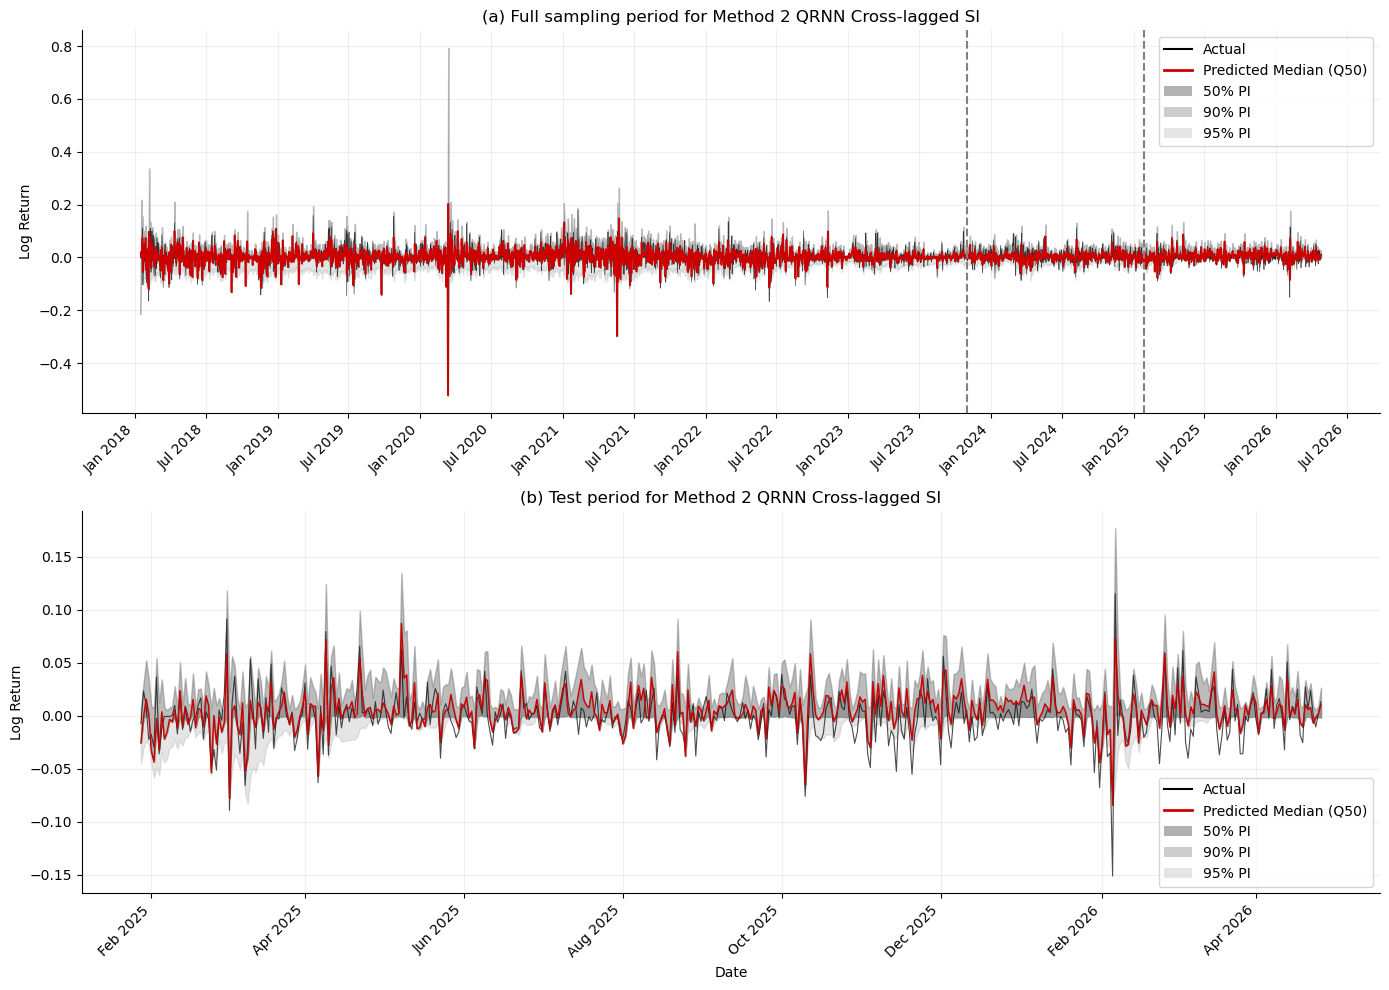

Plot saved to method2_sequential_qrnn_si_cross_predictions.png

TEST METRICS -- METHOD 2 QRNN SI CROSS-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -1.099689  0.292952 0.267952
 0.050 -1.290415  0.409692 0.359692
 0.250 -2.487635  0.409692 0.159692
 0.500 -2.724981  0.682819 0.182819
 0.750 -2.664895  0.682819 0.067181
 0.950 -2.282395  0.984581 0.034581
 0.975 -2.430856  0.984581 0.009581

Average NLL: -2.140124
Average HRE: 0.154500

CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

Metrics saved to method2_sequential_qrnn_si_cross_test_metrics.csv


In [30]:
# ============================================================
# Plot and evaluate Method 2
# Sequential QRNN SI Cross-lagged
# ============================================================

import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# Load checkpoint if models are not in memory
# ============================================================

if 'm2_qrnn_cross_si_final_models' not in globals():
    checkpoint = torch.load(
        'method2_sequential_qrnn_si_cross_best.pt',
        map_location='cpu',
        weights_only=False
    )

    m2_qrnn_cross_si_final_models = {}

    for alpha in checkpoint['estimation_order']:
        saved_model = checkpoint[
            'models'
        ][str(alpha)]

        model = M2SequentialQRNNSICross(
            input_dim=X_train.shape[1],
            config=saved_model['config'],
            direction=saved_model['direction']
        )

        model.load_state_dict(
            saved_model['state_dict']
        )

        model.eval()

        m2_qrnn_cross_si_final_models[
            alpha
        ] = model


# ============================================================
# Full-sample tensors
# ============================================================

m2_qrnn_cross_si_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32
)

m2_qrnn_cross_si_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32
)


# ============================================================
# Generate all levels sequentially
# ============================================================

m2_qrnn_cross_si_all_predictions = {}
m2_qrnn_cross_si_all_caviar = {}
m2_qrnn_cross_si_all_fnn = {}
m2_qrnn_cross_si_all_sigma = {}

for alpha in m2_qrnn_cross_si_order:
    model = m2_qrnn_cross_si_final_models[
        alpha
    ]

    reference_alpha = (
        m2_qrnn_cross_si_reference[
            alpha
        ]
    )

    if reference_alpha is None:
        reference_prediction = None
    else:
        reference_prediction = (
            m2_qrnn_cross_si_all_predictions[
                reference_alpha
            ]
        )

    model.eval()

    with torch.no_grad():
        (
            prediction,
            sigma,
            caviar_output,
            fnn_output
        ) = model(
            y=m2_qrnn_cross_si_y_all,
            X=m2_qrnn_cross_si_X_all,
            reference=reference_prediction
        )

    m2_qrnn_cross_si_all_predictions[
        alpha
    ] = prediction.detach()

    m2_qrnn_cross_si_all_caviar[
        alpha
    ] = caviar_output.detach()

    m2_qrnn_cross_si_all_fnn[
        alpha
    ] = fnn_output.detach()

    m2_qrnn_cross_si_all_sigma[
        alpha
    ] = sigma.detach()


m2_qrnn_cross_si_all_preds_np = {
    alpha: prediction.cpu().numpy()
    for alpha, prediction
    in m2_qrnn_cross_si_all_predictions.items()
}


# ============================================================
# Sample information
# ============================================================

m2_qrnn_cross_si_test_start = (
    len(train_df) + len(val_df)
)

m2_qrnn_cross_si_all_dates = df.index
m2_qrnn_cross_si_test_dates = test_df.index

m2_qrnn_cross_si_y_all_np = (
    df['log_return'].values
)

m2_qrnn_cross_si_y_test_np = (
    test_df['log_return'].values
)


# ============================================================
# Plot
# ============================================================

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'

legend_elements = [
    Line2D(
        [0], [0],
        color=actual_color,
        label='Actual'
    ),
    Line2D(
        [0], [0],
        color=median_color,
        linewidth=2,
        label='Predicted Median (Q50)'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.60,
        label='50% PI'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.40,
        label='90% PI'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.20,
        label='95% PI'
    )
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)


# Full sample
ax = axes[0]

ax.plot(
    m2_qrnn_cross_si_all_dates,
    m2_qrnn_cross_si_y_all_np,
    color=actual_color,
    linewidth=0.5,
    alpha=0.7
)

ax.plot(
    m2_qrnn_cross_si_all_dates,
    m2_qrnn_cross_si_all_preds_np[0.500],
    color=median_color,
    linewidth=1.2
)

ax.fill_between(
    m2_qrnn_cross_si_all_dates,
    m2_qrnn_cross_si_all_preds_np[0.025],
    m2_qrnn_cross_si_all_preds_np[0.975],
    color=interval_color,
    alpha=0.20
)

ax.fill_between(
    m2_qrnn_cross_si_all_dates,
    m2_qrnn_cross_si_all_preds_np[0.050],
    m2_qrnn_cross_si_all_preds_np[0.950],
    color=interval_color,
    alpha=0.40
)

ax.fill_between(
    m2_qrnn_cross_si_all_dates,
    m2_qrnn_cross_si_all_preds_np[0.250],
    m2_qrnn_cross_si_all_preds_np[0.750],
    color=interval_color,
    alpha=0.60
)

ax.axvline(
    train_df.index[-1],
    color='gray',
    linestyle='--'
)

ax.axvline(
    val_df.index[-1],
    color='gray',
    linestyle='--'
)

ax.set_title(
    '(a) Full sampling period for '
    'Method 2 QRNN Cross-lagged SI'
)

ax.set_ylabel('Log Return')
ax.legend(handles=legend_elements)
ax.grid(True, alpha=0.2)


# Test sample
ax2 = axes[1]

test_slice = slice(
    m2_qrnn_cross_si_test_start,
    None
)

ax2.plot(
    m2_qrnn_cross_si_test_dates,
    m2_qrnn_cross_si_y_test_np,
    color=actual_color,
    linewidth=0.8,
    alpha=0.7
)

ax2.plot(
    m2_qrnn_cross_si_test_dates,
    m2_qrnn_cross_si_all_preds_np[
        0.500
    ][test_slice],
    color=median_color,
    linewidth=1.0
)

ax2.fill_between(
    m2_qrnn_cross_si_test_dates,
    m2_qrnn_cross_si_all_preds_np[
        0.025
    ][test_slice],
    m2_qrnn_cross_si_all_preds_np[
        0.975
    ][test_slice],
    color=interval_color,
    alpha=0.20
)

ax2.fill_between(
    m2_qrnn_cross_si_test_dates,
    m2_qrnn_cross_si_all_preds_np[
        0.050
    ][test_slice],
    m2_qrnn_cross_si_all_preds_np[
        0.950
    ][test_slice],
    color=interval_color,
    alpha=0.40
)

ax2.fill_between(
    m2_qrnn_cross_si_test_dates,
    m2_qrnn_cross_si_all_preds_np[
        0.250
    ][test_slice],
    m2_qrnn_cross_si_all_preds_np[
        0.750
    ][test_slice],
    color=interval_color,
    alpha=0.60
)

ax2.set_title(
    '(b) Test period for '
    'Method 2 QRNN Cross-lagged SI'
)

ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.legend(handles=legend_elements)
ax2.grid(True, alpha=0.2)


for axis, interval in zip(
    axes,
    [6, 2]
):
    axis.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )

    axis.xaxis.set_major_locator(
        mdates.MonthLocator(
            interval=interval
        )
    )

    plt.setp(
        axis.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

plt.tight_layout()

m2_qrnn_cross_si_plot_name = (
    'method2_sequential_qrnn_si_cross_predictions.png'
)

plt.savefig(
    m2_qrnn_cross_si_plot_name,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(
    f'Plot saved to '
    f'{m2_qrnn_cross_si_plot_name}'
)


# ============================================================
# Test metrics
# ============================================================

m2_qrnn_cross_si_y_test = (
    m2_qrnn_cross_si_y_all[
        m2_qrnn_cross_si_test_start:
    ]
)

metric_rows = []

for alpha in m2_qrnn_cross_si_alpha_levels:
    q_test = (
        m2_qrnn_cross_si_all_predictions[
            alpha
        ][m2_qrnn_cross_si_test_start:]
    )

    sigma = (
        m2_qrnn_cross_si_all_sigma[
            alpha
        ]
    )

    test_nll = m2_qrnn_cross_si_loss(
        y=m2_qrnn_cross_si_y_test,
        q_hybrid=q_test,
        sigma=sigma,
        alpha=alpha
    ).item()

    hit_rate, test_hre = (
        m2_qrnn_cross_si_compute_hre(
            y=m2_qrnn_cross_si_y_test,
            q_hybrid=q_test,
            alpha=alpha
        )
    )

    metric_rows.append({
        'alpha': alpha,
        'NLL': test_nll,
        'Hit_Rate': hit_rate,
        'HRE': test_hre
    })


m2_qrnn_cross_si_metrics_df = (
    pd.DataFrame(metric_rows)
)

average_nll = (
    m2_qrnn_cross_si_metrics_df[
        'NLL'
    ].mean()
)

average_hre = (
    m2_qrnn_cross_si_metrics_df[
        'HRE'
    ].mean()
)

print('\n' + '=' * 68)
print(
    'TEST METRICS -- METHOD 2 '
    'QRNN SI CROSS-LAGGED'
)
print('=' * 68)

print(
    m2_qrnn_cross_si_metrics_df.to_string(
        index=False
    )
)

print(
    f'\nAverage NLL: {average_nll:.6f}'
)

print(
    f'Average HRE: {average_hre:.6f}'
)


# ============================================================
# Crossover analysis
# ============================================================

adjacent_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975)
]

tail_pairs = [
    (0.025, 0.050),
    (0.950, 0.975)
]

total_violations = 0
tail_violations = 0
crossover_rows = []

print('\n' + '=' * 68)
print(
    'CROSSOVER ANALYSIS -- '
    'FINAL METHOD 2 HYBRID OUTPUT'
)
print('=' * 68)

for lower, upper in adjacent_pairs:
    lower_test = (
        m2_qrnn_cross_si_all_predictions[
            lower
        ][m2_qrnn_cross_si_test_start:]
    )

    upper_test = (
        m2_qrnn_cross_si_all_predictions[
            upper
        ][m2_qrnn_cross_si_test_start:]
    )

    violations = int(
        (
            lower_test > upper_test
        ).sum().item()
    )

    rate = (
        violations / len(lower_test)
    )

    total_violations += violations

    if (lower, upper) in tail_pairs:
        tail_violations += violations

    crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': violations,
        'Rate': rate
    })

    tail_label = (
        ' <-- TAIL'
        if (lower, upper) in tail_pairs
        else ''
    )

    print(
        f'({lower:.3f}, {upper:.3f}): '
        f'{violations} '
        f'({100 * rate:.2f}%)'
        f'{tail_label}'
    )


total_rate = (
    total_violations
    / (
        len(m2_qrnn_cross_si_y_test)
        * 6
    )
)

tail_rate = (
    tail_violations
    / (
        len(m2_qrnn_cross_si_y_test)
        * 2
    )
)

print(
    f'\nTotal violations: '
    f'{total_violations} '
    f'({100 * total_rate:.2f}%)'
)

print(
    f'Tail violations: '
    f'{tail_violations} '
    f'({100 * tail_rate:.2f}%)'
)


# ============================================================
# Save results
# ============================================================

m2_qrnn_cross_si_metrics_df.to_csv(
    'method2_sequential_qrnn_si_cross_test_metrics.csv',
    index=False
)

pd.DataFrame(
    crossover_rows
).to_csv(
    'method2_sequential_qrnn_si_cross_crossover.csv',
    index=False
)

print(
    '\nMetrics saved to '
    'method2_sequential_qrnn_si_cross_test_metrics.csv'
)

# Cross over dealing3

In [33]:
"""Method 3, Specification 1: Hybrid QRNN SI cross-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("method3_spacing_qrnn_si_cross_results")

# This standalone chunk estimates only the model supplied by the user:
# Hybrid QRNN, symmetric indirect form, cross-lagged recursion.
MODELS_TO_RUN = [("qrnn", "si", "cross")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "method3_qrnn_si_cross_validation_summary.csv", index=False
        )
    print("\nMethod 3 QRNN SI cross-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-08-16 14:41:49,833] A new study created in memory with name: no-name-b8be82f9-ee47-4e7c-a0b0-04a257f6f079



METHOD 3 SPACING: QRNN SI CROSS
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 14:42:26,117] Trial 0 finished with value: 1.3081965446472168 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3081965446472168.
[I 2026-08-16 14:43:00,028] Trial 1 finished with value: 0.2545832693576813 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2545832693576813.
[I 2026-08-16 14:43:04,092] Trial 2 finished with value: 1.4296633005142212 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': True, '

[I 2026-08-16 17:14:00,134] A new study created in memory with name: no-name-be02c93f-2062-4935-b0b1-6379c87d77a3


...

[I 2026-08-16 18:16:03,347] Trial 0 finished with value: 1.9725486040115356 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9725486040115356.
[I 2026-08-16 18:16:08,241] Trial 1 finished with value: 0.7042379975318909 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.7042379975318909.
[I 2026-08-16 18:16:10,900] Trial 2 finished with value: 2.9178354740142822 and parameters: {'n_hidden_layers': 2, 'activat

[I 2026-08-16 18:22:34,632] A new study created in memory with name: no-name-73dbf7ee-fec5-4d4b-822c-ae61bc89e51a


Selected trial #173 | val NLL=-2.463230 | calibration=1.059603 | mean delta=0.012159
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 18:22:41,214] Trial 0 finished with value: 2.489833354949951 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.489833354949951.
[I 2026-08-16 18:22:47,403] Trial 1 finished with value: 3.3954403400421143 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 2.489833354949951.
[I 2026-08-16 18:22:49,375] Trial 2 finished with value: 3.5395965576171875 and parameters: {'n_hidden_lay

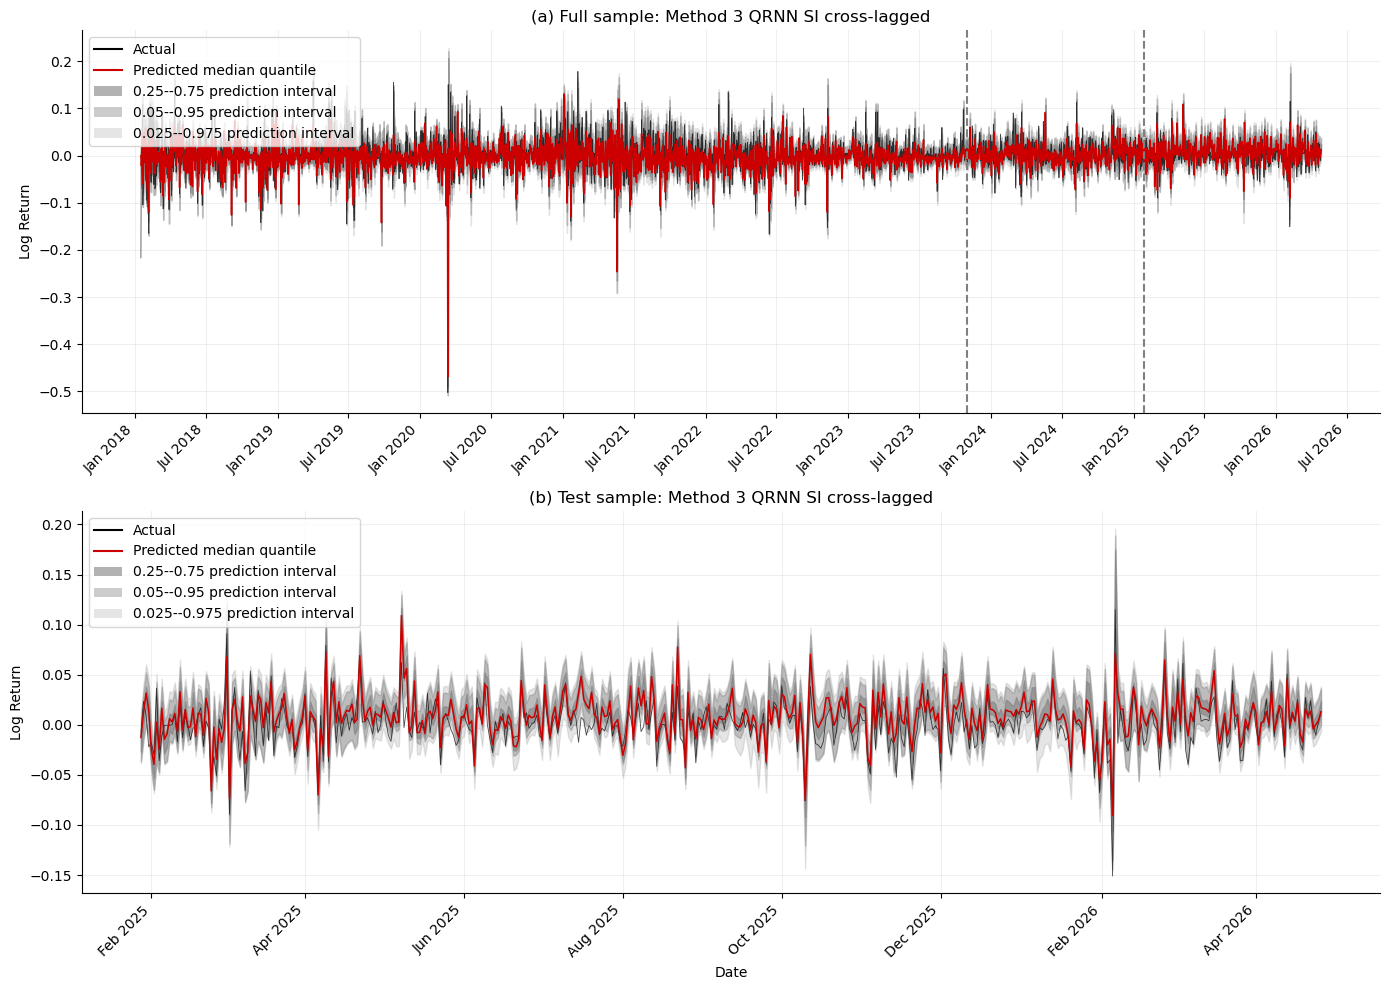


METHOD 3 QRNN SI CROSS-LAGGED -- TEST RESULTS
                 model  test_T  average_nll  average_hre  crossover  tail
Method 3 QRNN SI Cross     454    -2.426749     0.143172          0     0

Per-level results:
 alpha       nll  hit_rate      hre    sigma
 0.025 -2.303343  0.070485 0.045485 0.000858
 0.050 -2.204080  0.198238 0.148238 0.001555
 0.250 -2.504378  0.566079 0.316079 0.005269
 0.500 -2.638765  0.753304 0.253304 0.009303
 0.750 -2.646363  0.920705 0.170705 0.004634
 0.950 -2.408074  0.993392 0.043392 0.001482
 0.975 -2.282242  1.000000 0.025000 0.000908

Learned-spacing diagnostics:
 alpha  reference_alpha direction  mean_delta  min_delta  max_delta  sd_delta  near_zero_count  near_zero_rate
 0.025             0.05     lower    0.007934   0.000174   0.029185  0.005603                0             0.0
 0.050             0.25     lower    0.012163   0.001436   0.055225  0.007372                0             0.0
 0.250             0.50     lower    0.006191   0.002006   0.0

In [35]:
"""Plot and evaluate Method 3 QRNN SI cross-lagged on the test sample.

Run after the tuning/data-preparation code. Expected notebook objects:
df, train_df, val_df, test_df, feature_cols, X_train and Method3SpacingModel.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

MODEL_DIR = Path("method3_spacing_qrnn_si_cross_results") / "qrnn_si_cross"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_qrnn_si_cross_best.pt"
PLOT_PATH = MODEL_DIR / "method3_spacing_qrnn_si_cross.png"
METRICS_PATH = MODEL_DIR / "method3_spacing_qrnn_si_cross_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "method3_spacing_qrnn_si_cross_test_summary.csv"
DELTA_PATH = MODEL_DIR / "method3_spacing_qrnn_si_cross_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "method3_spacing_qrnn_si_cross_test_predictions.csv"


required_objects = (
    "df", "train_df", "val_df", "test_df", "feature_cols", "X_train"
)
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError("Run the data-preparation cells first. Missing: " + ", ".join(missing))

if "Method3SpacingModel" not in globals():
    from method3_spacing_qrnn_si_cross_tuning import Method3SpacingModel

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Run the tuning code first."
    )


# ---------------------------------------------------------------------------
# Reload all seven selected level models
# ---------------------------------------------------------------------------

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "qrnn":
    raise ValueError("The checkpoint is not a QRNN checkpoint.")
if checkpoint.get("form") != "si" or checkpoint.get("lag") != "cross":
    raise ValueError("The checkpoint is not the QRNN SI cross-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="qrnn",
        form="si",
        lag="cross",
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model


# ---------------------------------------------------------------------------
# Generate full-sample forecasts sequentially from the median outwards
# ---------------------------------------------------------------------------

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index

if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")


# ---------------------------------------------------------------------------
# Plot full sample and test sample
# ---------------------------------------------------------------------------

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}
actual_np = df["log_return"].to_numpy()


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(dates, values(0.025), values(0.975), color="#808080", alpha=0.20)
    axis.fill_between(dates, values(0.050), values(0.950), color="#808080", alpha=0.40)
    axis.fill_between(dates, values(0.250), values(0.750), color="#808080", alpha=0.60)
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, actual_np)
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 QRNN SI cross-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start)
axes[1].set_title("(b) Test sample: Method 3 QRNN SI cross-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median quantile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 prediction interval"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 prediction interval"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 prediction interval"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------------------------
# Test ALD NLL, hit rate and HRE
# ---------------------------------------------------------------------------


def ald_nll(y, quantile, sigma, alpha):
    residual = y - quantile
    alpha_tensor = torch.tensor(alpha, dtype=y.dtype, device=y.device)
    indicator = (residual < 0).to(y.dtype)
    check_loss = residual * (alpha_tensor - indicator)
    return (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma)
        + check_loss / sigma
    ).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    hit_rate = (y_test <= prediction_test).float().mean().item()
    metric_rows.append({
        "alpha": level,
        "nll": ald_nll(y_test, prediction_test, sigmas[level], level).item(),
        "hit_rate": hit_rate,
        "hre": abs(hit_rate - level),
        "sigma": sigmas[level].item(),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)


# ---------------------------------------------------------------------------
# Crossover and learned-spacing diagnostics
# ---------------------------------------------------------------------------

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "alpha": level,
        "reference_alpha": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 QRNN SI Cross",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_hre": metrics_df["hre"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)


# ---------------------------------------------------------------------------
# Detailed test predictions and adjacent gaps
# ---------------------------------------------------------------------------

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"q_{level:.3f}"] = predictions[level][test_start:].cpu().numpy()
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)


print("\nMETHOD 3 QRNN SI CROSS-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")